# Experiment 4 - W-estimate skill summary

Presentation figures built from `data/metrics.csv` and the per-cell arrays saved
by `run_experiment_4.py`: an overview (fig1), skill vs array width (fig2 plus the
per-method breakdowns fig2a-2d), skill vs cell latitude (fig3), skill vs
gliders-per-cell (fig4), and skill vs depth per method (fig5a-5d). Every metric is
a plain descriptive statistic (RMS, RMS normalized by the signal std, correlation,
bias) - no thresholds or 'best config' judgements are baked in; those are left to
discuss.

Run in place after `run_experiment_4.py` has populated `data/`.

In [1]:
import os, sys
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

REPO = "/home/edavenport/analysis/tpose24-osse"
HERE = os.path.join(REPO, "experiment_4")
sys.path.insert(0, REPO)
import osse_tools as ot

DATA   = os.path.join(HERE, "data")
SUMDIR = os.path.join(HERE, "summary_figs"); os.makedirs(SUMDIR, exist_ok=True)
plt.rcParams["figure.dpi"] = 120

m = pd.read_csv(os.path.join(DATA, "metrics.csv"))
FAM_COLORS = {"shift": "C0", "equator": "C1", "density": "C2"}

def load_cell(row):
    """Open the saved w_est/w_model/bias arrays for one metrics row."""
    return xr.open_dataset(os.path.join(HERE, row.nc_path))

print(f"{len(m)} config cells across {m.config.nunique()} configs")
m.head()

96 config cells across 66 configs


,config,family,pattern,width,center_lat,n_gliders_cell,n_gliders_total,cell_height_deg,min_depth,max_depth,nc_path,rms,mean_bias,corr,w_est_std,w_model_std,w_model_mean,norm_rms,n
0,density_2g_w0.25,density,density_2g,0.25,0.5,2,2,1.0,8,120,data/density_2g_w0.25__cell_+0.50.nc,0.000038,-4.472283e-06,0.895311,0.000084,0.000082,0.000005,0.467382,36936
1,density_2g_w0.5,density,density_2g,0.50,0.5,2,2,1.0,8,120,data/density_2g_w0.5__cell_+0.50.nc,0.000029,-5.108082e-06,0.929583,0.000076,0.000078,0.000004,0.378451,36936
2,density_2g_w0.75,density,density_2g,0.75,0.5,2,2,1.0,8,120,data/density_2g_w0.75__cell_+0.50.nc,0.000029,-2.450423e-06,0.924154,0.000074,0.000074,0.000003,0.391045,36936
3,density_2g_w1.0,density,density_2g,1.00,0.5,2,2,1.0,8,120,data/density_2g_w1.0__cell_+0.50.nc,0.000034,-1.016817e-06,0.887225,0.000073,0.000071,0.000004,0.481063,36936
4,density_2g_w1.5,density,density_2g,1.50,0.5,2,2,1.0,8,120,data/density_2g_w1.5__cell_+0.50.nc,0.000043,7.050852e-07,0.815587,0.000074,0.000067,0.000004,0.646820,36936


## Figure 1 - skill by array family (how good, and does design matter?)

Skill distribution of every config cell, split by array family and coloured by
array width. The dashed line at `RMS/sigma = 1` is the no-skill reference (an
estimate of zero). Replaces the earlier error-vs-signal / error-vs-correlation
overview: that pair was uninformative because every config beats the trivial
`RMS = signal` line, and normalized error and correlation are two views of the
same quantity so plotting them against each other only shows they agree.

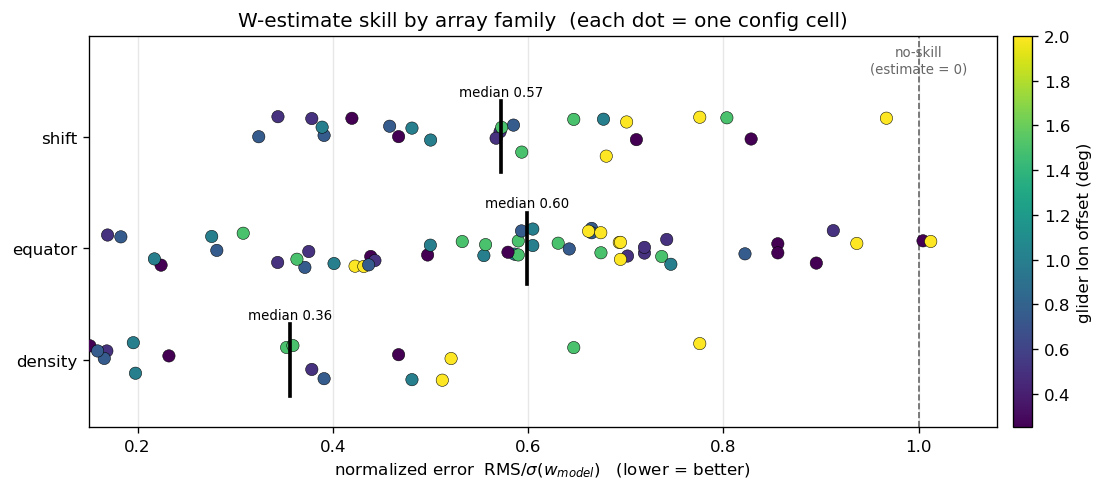

In [2]:
# Figure 1 - skill distribution by array family (each dot = one config cell).
# x = normalized error RMS/sigma (lower is better); dots coloured by array width
# so the within-family spread is explained; black bar = family median;
# dashed line = no-skill reference (estimate = 0 => RMS/sigma = 1).
fams = ["density", "equator", "shift"]          # best -> worst, top -> bottom
ypos = {f: i for i, f in enumerate(fams)}
rng = np.random.default_rng(0)

fig, ax = plt.subplots(figsize=(10, 4.2))
sc = None
for f in fams:
    s = m[m.family == f]
    jit = rng.uniform(-0.18, 0.18, len(s))
    sc = ax.scatter(s.norm_rms, ypos[f] + jit, c=s.width, cmap="viridis",
                    vmin=m.width.min(), vmax=m.width.max(),
                    s=55, edgecolor="k", lw=0.3, zorder=3)
    med = s.norm_rms.median()
    ax.plot([med, med], [ypos[f] - 0.32, ypos[f] + 0.32], "k-", lw=2.2, zorder=4)
    ax.text(med, ypos[f] + 0.34, f"median {med:.2f}", ha="center", va="bottom",
            fontsize=8)

ax.axvline(1.0, color="0.4", ls="--", lw=1)
ax.text(1.0, len(fams) - 0.45, "no-skill\n(estimate = 0)", color="0.4",
        fontsize=8, ha="center", va="bottom")

ax.set_yticks(range(len(fams)))
ax.set_yticklabels(fams)
ax.set_ylim(-0.6, len(fams) - 0.1)
ax.set_xlim(0.15, 1.08)
ax.set_xlabel(r"normalized error  RMS/$\sigma(w_{model})$   (lower = better)")
ax.set_title("W-estimate skill by array family  (each dot = one config cell)")
ax.grid(axis="x", alpha=0.3)
cb = fig.colorbar(sc, ax=ax, pad=0.015)
cb.set_label("glider lon offset (deg)")
fig.tight_layout()
fig.savefig(os.path.join(SUMDIR, "fig1_skill_overview.png"), dpi=150, bbox_inches="tight")
plt.show()

## Figure 2 - skill vs array width

One line per (method, estimate location). **Colour = where the estimate is
centred** (`center_lat`), so estimates at the same latitude share a colour;
**linestyle + marker = method** (the sampling pattern). This disaggregates the
multi-cell arrays, which the earlier one-line-per-pattern version hid by
averaging over cells at different latitudes.

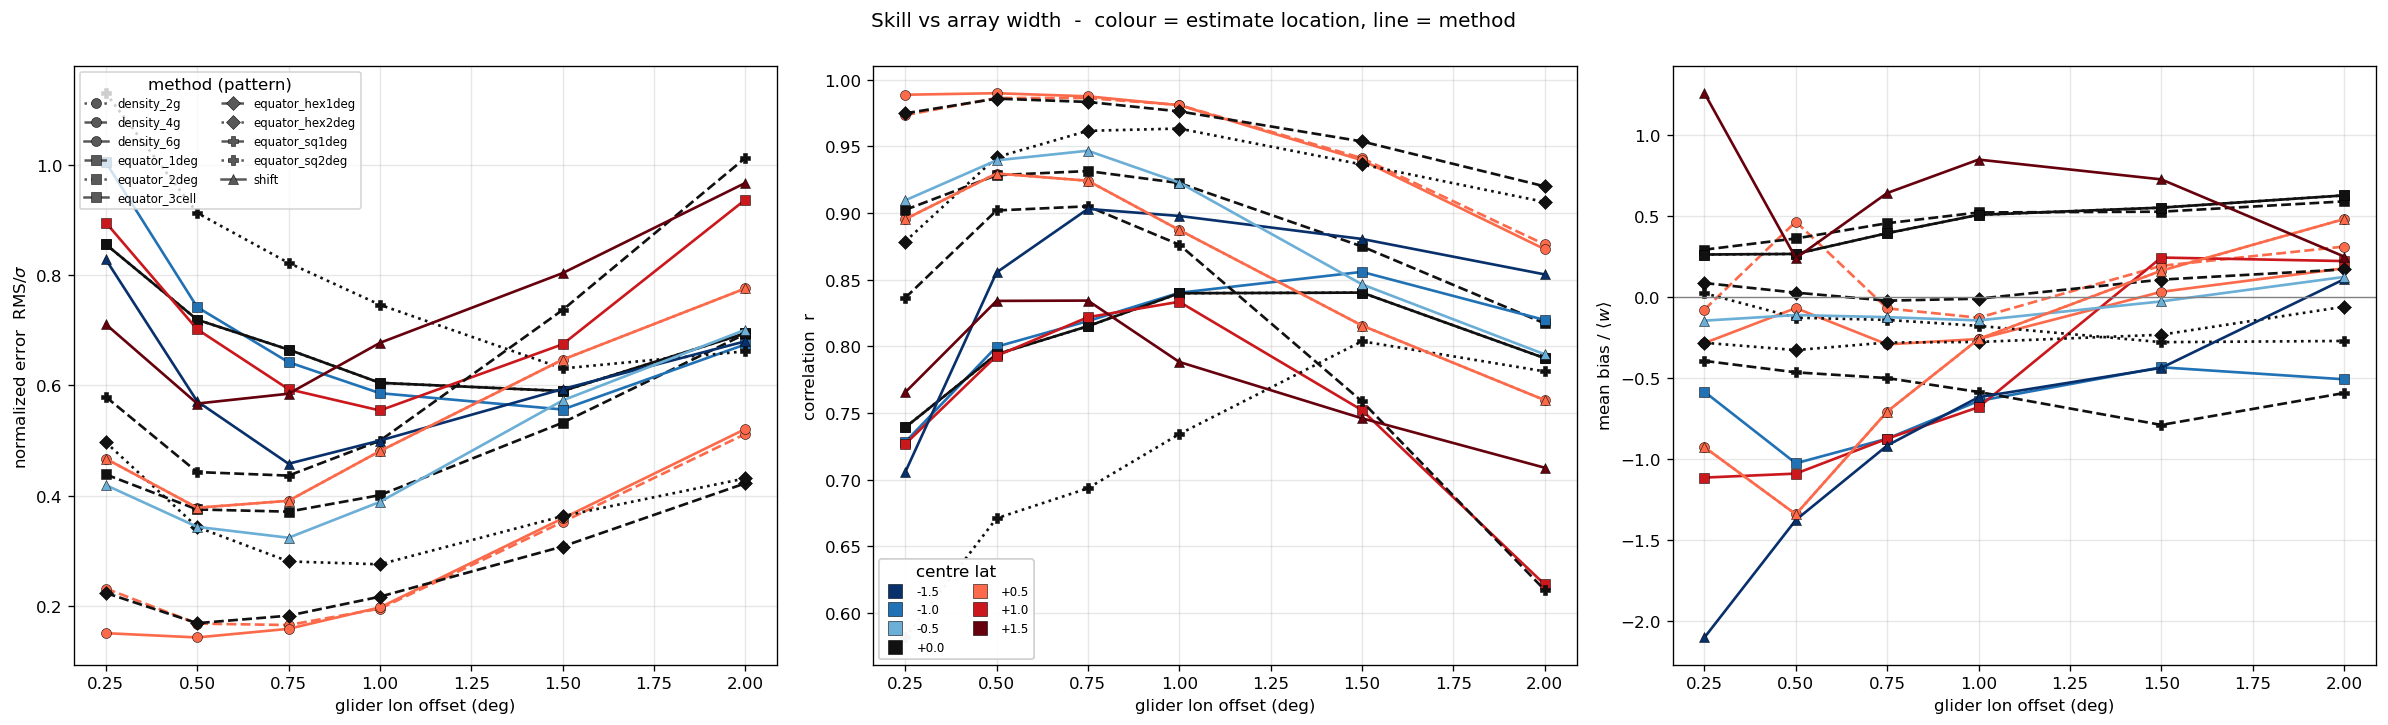

In [3]:
# Figure 2 - skill vs array width, one line per (method, estimate location).
# COLOUR = centre latitude (where the estimate sits): blues south, black
# equator, reds north -> same-location estimates share a colour.
# LINESTYLE + MARKER = method (pattern): marker groups the geometry
# (o density, s equator diamond, D equator hexagon, ^ shift), linestyle the variant.
LAT_COLORS = {
    -1.5: "#08306b", -1.0: "#2171b5", -0.5: "#6baed6",
     0.0: "#111111",
     0.5: "#fb6a4a",  1.0: "#cb181d",  1.5: "#67000d",
}
PAT_STYLE = {
    "density_2g":      (":",  "o"), "density_4g":    ("--", "o"),
    "density_6g":      ("-",  "o"),
    "equator_1deg":    ("--", "s"), "equator_2deg":  (":",  "s"),
    "equator_3cell":   ("-",  "s"),
    "equator_hex1deg": ("--", "D"), "equator_hex2deg": (":", "D"),
    "equator_sq1deg":  ("--", "P"), "equator_sq2deg":  (":", "P"),
    "shift":           ("-",  "^"),
}

g = (m.groupby(["family", "pattern", "center_lat", "width"], as_index=False)
       [["norm_rms", "corr", "mean_bias", "w_model_mean"]].mean())

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for (pat, lat), d in g.groupby(["pattern", "center_lat"]):
    d = d.sort_values("width")
    ls, mk = PAT_STYLE[pat]
    col = LAT_COLORS[lat]
    axes[0].plot(d.width, d.norm_rms, ls=ls, marker=mk, color=col, lw=1.6,
                 ms=6, mec="k", mew=0.3)
    axes[1].plot(d.width, d["corr"], ls=ls, marker=mk, color=col, lw=1.6,
                 ms=6, mec="k", mew=0.3)
    axes[2].plot(d.width, ot.frac_mean_bias(d.mean_bias, d.w_model_mean),
                 ls=ls, marker=mk, color=col, lw=1.6, ms=6, mec="k", mew=0.3)
axes[0].set_ylabel(r"normalized error  RMS/$\sigma$")
axes[1].set_ylabel("correlation  r")
axes[2].set_ylabel(r"mean bias / $\langle w \rangle$")
axes[2].axhline(0, color="0.5", lw=0.8)
for ax in axes:
    ax.set_xlabel("glider lon offset (deg)"); ax.grid(alpha=0.3)

# two legends: colour = estimate location, line = method
from matplotlib.lines import Line2D
lat_handles = [Line2D([0], [0], marker="s", ls="", mfc=LAT_COLORS[l], mec="k",
                      mew=0.3, ms=8, label=f"{l:+.1f}")
               for l in sorted(LAT_COLORS)]
pat_handles = [Line2D([0], [0], color="0.35", ls=PAT_STYLE[p][0],
                      marker=PAT_STYLE[p][1], mfc="0.35", mec="k", mew=0.3,
                      label=p) for p in PAT_STYLE]
leg1 = axes[1].legend(handles=lat_handles, title="centre lat", fontsize=7,
                      loc="lower left", ncol=2)
axes[1].add_artist(leg1)
axes[0].legend(handles=pat_handles, title="method (pattern)", fontsize=7,
               loc="upper left", ncol=2)
fig.suptitle("Skill vs array width  -  colour = estimate location, line = method",
             y=1.0)
fig.tight_layout()
fig.savefig(os.path.join(SUMDIR, "fig2_skill_vs_width.png"), dpi=150, bbox_inches="tight")
plt.show()

## Figures 2a-2d - skill vs width, one method at a time

Per-method breakdown of the combined Figure 2, so each is readable. x = glider
lon offset throughout; each figure colours its lines by whatever is tuned within
that method (never by width), and carries a fourth panel with the platform layout
(squares = moorings, circles = gliders; offset drawn = 0.5°).

- **2a shift array** - one 4-cell array; colour = cell centre latitude
  (−1.5, −0.5, +0.5, +1.5). Layout stacked: the four 1°-tall cells tile lat −2→+2.
- **2b equator 3-cell** - colour = cell centre latitude (−1 / 0 / +1). Layout
  stacked: three 2°-tall cells sharing the −2…+2 moorings, each now using its
  interior centre mooring.
- **2c density** - centre fixed at +0.5, colour = gliders-per-cell; layout shows
  the 2/4/6-glider alternatives side by side.
- **2d equator single-cell** - centre fixed at 0.0. Compares **diamond vs hexagon**
  at **1° vs 2° tall**: colour = height (1° blue / 2° red), line/marker = shape
  (solid ◇ diamond, dashed ◈ hexagon). The hexagon adds mid-latitude side gliders
  (1° tall → 6 gliders, 2° tall → 4 gliders since its ±1° N/S sit on moorings).

Every cell also uses any interior mooring (the equator cells' centre mooring,
the 3-cell cells' centre moorings) — see generate_configs `_interior_moorings`.

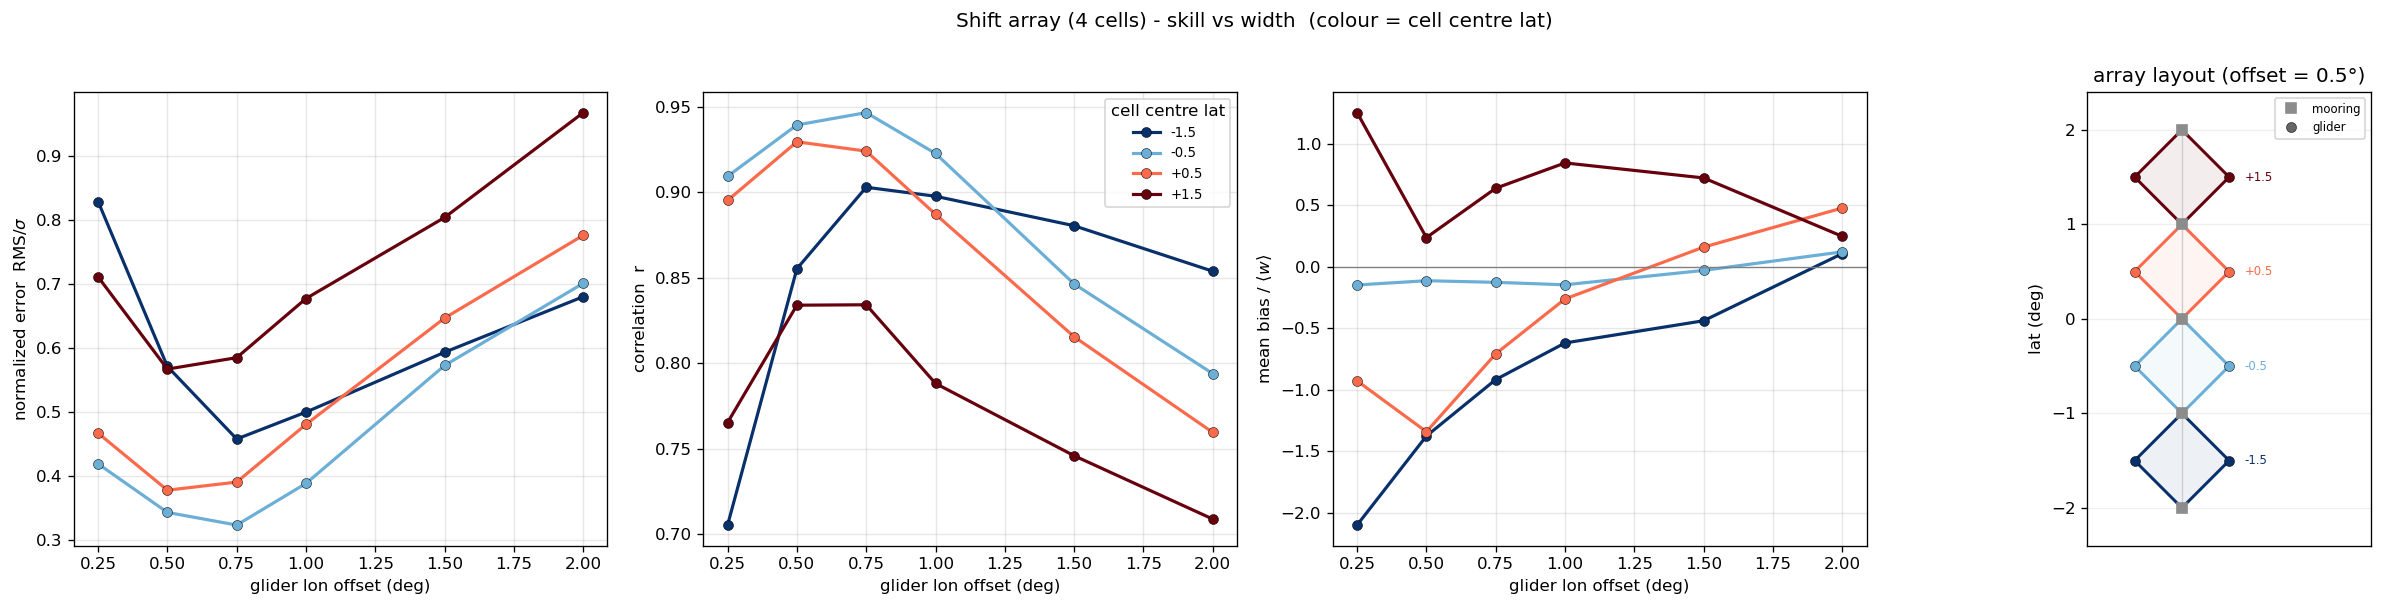

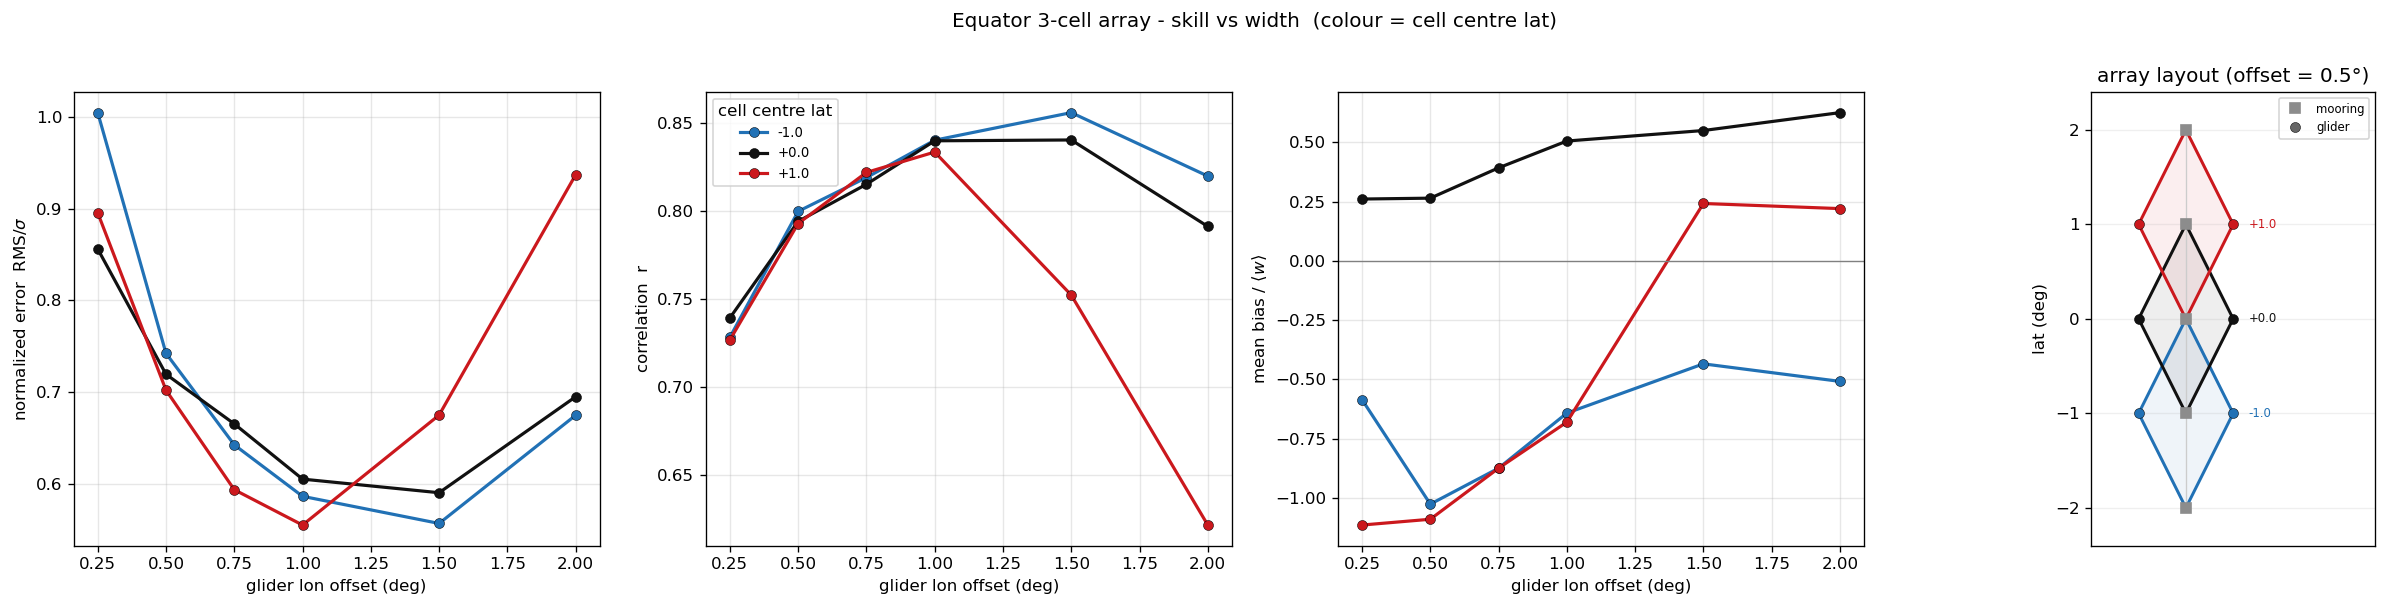

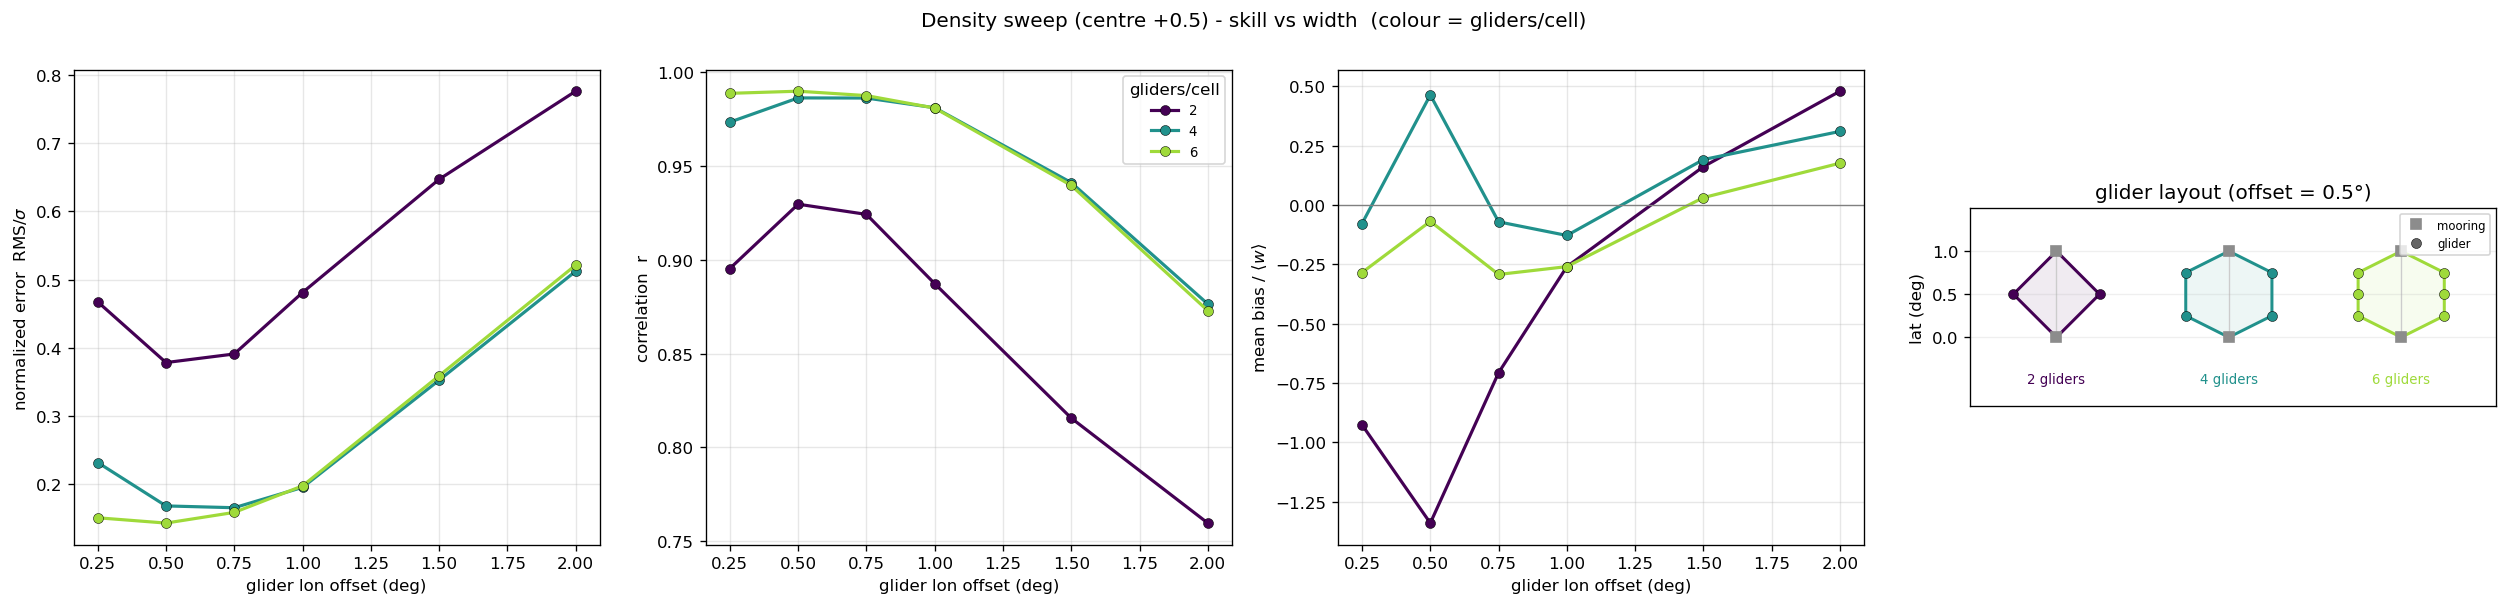

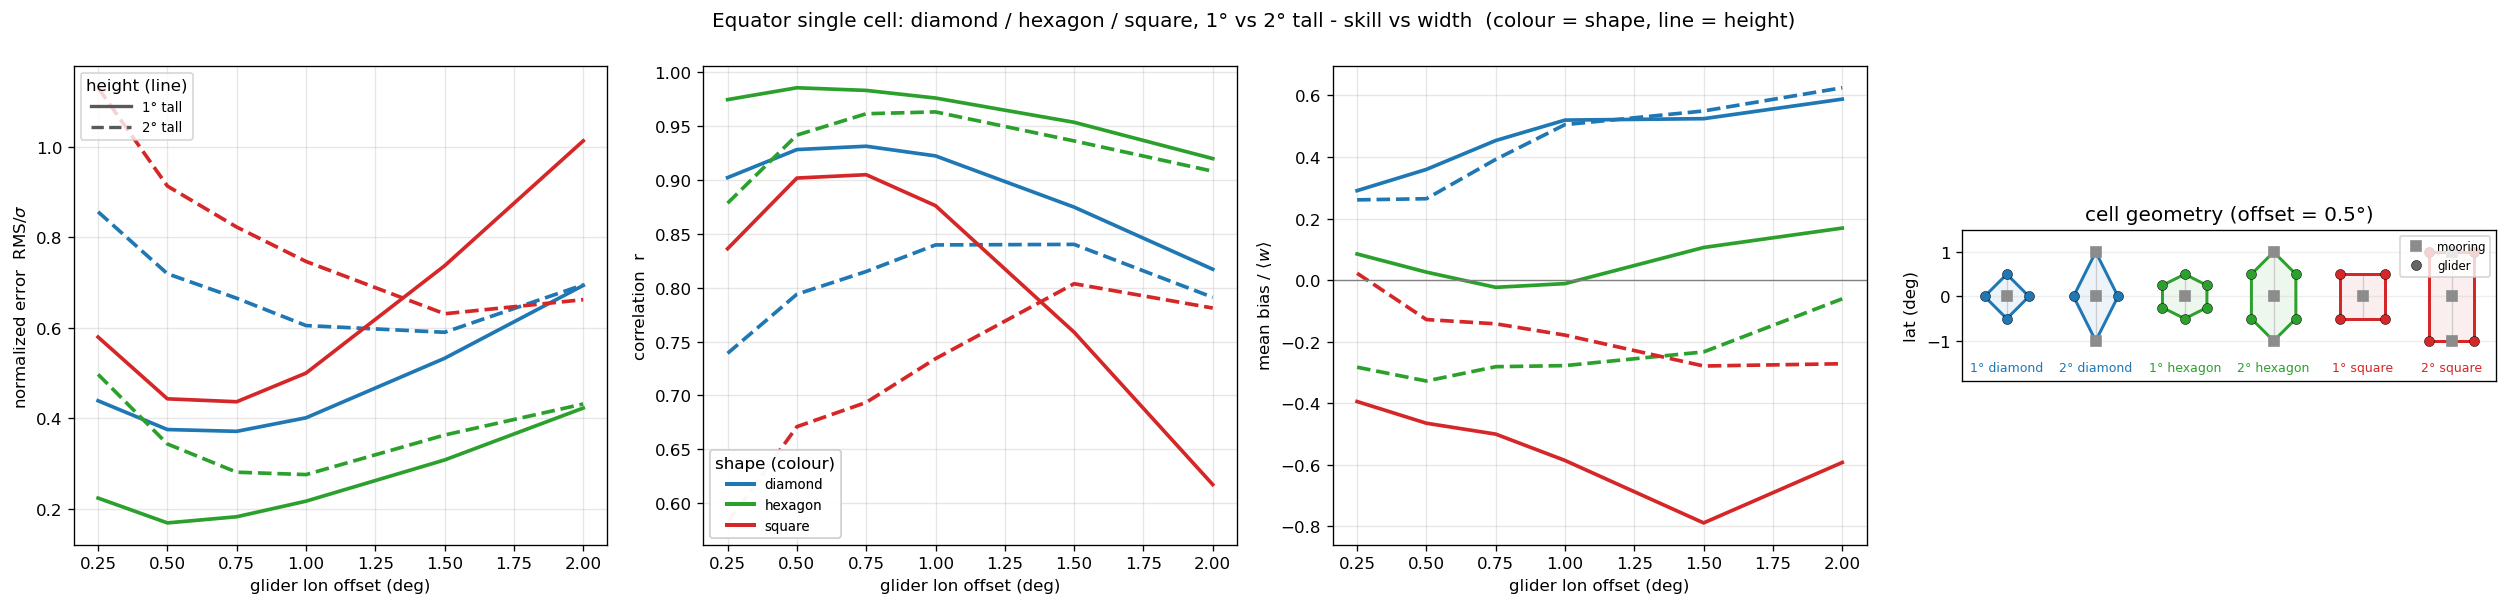

In [4]:
# Figures 2a-2d - skill vs width, one method per figure, each with a third panel
# showing the platform layout (offset drawn = 0.5 deg).
# Lines coloured by the parameter actually swept within that method (cell centre
# latitude / gliders-per-cell / cell height+shape) - never by width, the x-axis.
# Geometry panels: squares = moorings, circles = gliders, hull outline coloured to
# match the lines. Multi-cell ARRAYS (shift, 3-cell) are drawn stacked (the cells
# coexist); single-cell alternatives (density, equator single) side by side.
GLIDER_COLORS = {2: "#440154", 4: "#21918c", 6: "#9fda3a"}   # sequential
# equator single-cell: colour = SHAPE (diamond/hexagon/square), linestyle = cell
# HEIGHT (1deg solid / 2deg dashed). No markers, so the linestyle reads cleanly.
EQS_SHAPE_COLOR = {"diamond": "#1f77b4", "hexagon": "#2ca02c", "square": "#d62728"}
EQS_HEIGHT_LS   = {1.0: "-", 2.0: "--"}          # cell_height_deg -> linestyle
EQS_META = {                                     # pattern -> (shape, height_deg)
    "equator_1deg":    ("diamond", 1.0), "equator_2deg":    ("diamond", 2.0),
    "equator_hex1deg": ("hexagon", 1.0), "equator_hex2deg": ("hexagon", 2.0),
    "equator_sq1deg":  ("square",  1.0), "equator_sq2deg":  ("square",  2.0),
}
EQS_STYLE = {pat: dict(color=EQS_SHAPE_COLOR[sh], ls=EQS_HEIGHT_LS[h],
                       lbl=f"{h:g}° {sh}", shape=sh, height=h)
             for pat, (sh, h) in EQS_META.items()}
# grouped by shape, then height (colour then linestyle)
EQS_PATS = ["equator_1deg", "equator_2deg", "equator_hex1deg", "equator_hex2deg",
            "equator_sq1deg", "equator_sq2deg"]
# LAT_COLORS reused from the combined Figure 2 above (same location -> same colour)

def _lat_lbl(v): return f"{v:+.1f}"

def _hull_poly(pts):
    """Vertices of the convex outline of pts, angle-sorted (pts are convex)."""
    pts = np.array(pts, float)
    c = pts.mean(0)
    order = np.argsort(np.arctan2(pts[:, 1] - c[1], pts[:, 0] - c[0]))
    p = pts[order]
    return np.vstack([p, p[0]])          # closed

def _layout_legend(ax, loc="upper right"):
    ax.plot([], [], marker="s", ls="", color="0.55", ms=6, label="mooring")
    ax.plot([], [], marker="o", ls="", color="0.4", mec="k", mew=0.3, ms=6,
            label="glider")
    ax.legend(fontsize=7, loc=loc)

def _stacked_cells_panel(ax, cells, half, title, off_demo=0.5):
    """Vertical stack of diamond cells (an actual multi-cell array). Each cell is
    2*half deg tall with N/S vertices on the mooring line and E/W gliders at
    +/-off; points at integer lat on the line are moorings (incl. interior ones,
    now used by the estimate). Colour = cell centre lat."""
    vlats = sorted({c + s * half for c in cells for s in (-1, 1)} | set(cells))
    moor = [v for v in vlats if abs(v - round(v)) < 1e-9]
    ax.plot([0, 0], [min(vlats), max(vlats)], color="0.8", lw=0.8, zorder=1)
    ax.plot([0] * len(moor), moor, marker="s", ls="", color="0.55", ms=6, zorder=3)
    for c in cells:
        col = LAT_COLORS[c]
        ax.plot([-off_demo, off_demo], [c, c], marker="o", ls="", color=col,
                ms=6, mec="k", mew=0.3, zorder=4)                 # E/W gliders
        poly = _hull_poly([(0, c + half), (off_demo, c), (0, c - half), (-off_demo, c)])
        ax.plot(poly[:, 0], poly[:, 1], "-", color=col, lw=1.8, zorder=2)
        ax.fill(poly[:, 0], poly[:, 1], color=col, alpha=0.07, zorder=0)
        ax.text(off_demo + 0.16, c, f"{c:+.1f}", va="center", ha="left",
                fontsize=7, color=col)
    _layout_legend(ax, loc="upper right")
    ax.set_aspect("equal"); ax.set_xlim(-1.0, 2.0)
    ax.set_ylim(min(vlats) - 0.4, max(vlats) + 0.4)
    ax.set_xticks([]); ax.set_yticks(moor); ax.set_ylabel("lat (deg)")
    ax.set_title(title); ax.grid(alpha=0.2, axis="y")

def _density_geometry_panel(ax, off_demo=0.5):
    """Layouts of the 2/4/6-glider cells (centre +0.5): N/S moorings at lat 0/1,
    glider rows at +/-off. Hull outline coloured to match the lines."""
    rows_by_ng = {2: [0.5], 4: [0.25, 0.75], 6: [0.25, 0.5, 0.75]}
    for i, ng in enumerate((2, 4, 6)):
        xc, col = i * 2.0, GLIDER_COLORS[ng]
        ax.plot([xc, xc], [0, 1], color="0.8", lw=0.8, zorder=1)      # mooring line
        ax.plot([xc, xc], [0, 1], marker="s", ls="", color="0.55", ms=6, zorder=3)
        gl = [(xc + s * off_demo, r) for r in rows_by_ng[ng] for s in (-1, 1)]
        ax.plot([p[0] for p in gl], [p[1] for p in gl], marker="o", ls="",
                color=col, ms=6, mec="k", mew=0.3, zorder=4)         # gliders
        poly = _hull_poly([(xc, 0), (xc, 1)] + gl)
        ax.plot(poly[:, 0], poly[:, 1], "-", color=col, lw=1.8, zorder=2)
        ax.fill(poly[:, 0], poly[:, 1], color=col, alpha=0.08, zorder=0)
        ax.text(xc, -0.4, f"{ng} gliders", ha="center", va="top", fontsize=8,
                color=col)
    _layout_legend(ax)
    ax.set_aspect("equal"); ax.set_xlim(-1.0, 5.1); ax.set_ylim(-0.8, 1.5)
    ax.set_xticks([]); ax.set_yticks([0, 0.5, 1]); ax.set_ylabel("lat (deg)")
    ax.set_title("glider layout (offset = 0.5°)")
    ax.grid(alpha=0.2, axis="y")

def _draw_equator_cell(ax, xc, shape, half, color, label, off=0.5):
    """One equator single-cell layout (diamond, hexagon, or square) centred at
    x=xc. A point is a mooring iff it is on the lon line at an integer latitude:
    the centre 0 for every cell, plus the +/-1 N/S points for 2deg cells."""
    if shape == "diamond":
        verts = [(0, half), (off, 0), (0, -half), (-off, 0)]
    elif shape == "hexagon":
        mid = half / 2.0
        verts = [(0, half), (off, mid), (off, -mid), (0, -half), (-off, -mid), (-off, mid)]
    else:                                       # square (box): 4 corner gliders
        verts = [(off, half), (off, -half), (-off, -half), (-off, half)]
    # free real moorings on the lon line within the cell's lat span (incl. centre)
    line_moor = [(0.0, ml) for ml in (-2, -1, 0, 1, 2) if -half - 1e-9 <= ml <= half + 1e-9]
    pts = verts + [p for p in line_moor if p not in verts]
    is_moor = lambda x, y: abs(x) < 1e-9 and abs(y - round(y)) < 1e-9
    ax.plot([xc, xc], [-half, half], color="0.8", lw=0.8, zorder=1)
    mo = [(xc + x, y) for x, y in pts if is_moor(x, y)]
    gl = [(xc + x, y) for x, y in pts if not is_moor(x, y)]
    ax.plot([p[0] for p in mo], [p[1] for p in mo], marker="s", ls="",
            color="0.55", ms=6, zorder=3)
    ax.plot([p[0] for p in gl], [p[1] for p in gl], marker="o", ls="",
            color=color, ms=6, mec="k", mew=0.3, zorder=4)
    poly = _hull_poly([(xc + x, y) for x, y in verts])
    ax.plot(poly[:, 0], poly[:, 1], "-", color=color, lw=1.8, zorder=2)
    ax.fill(poly[:, 0], poly[:, 1], color=color, alpha=0.08, zorder=0)
    ax.text(xc, -1.45, label, ha="center", va="top", fontsize=7.5, color=color)

def _equator_single_geometry(ax):
    # colour = shape (matches the lines); 1deg then 2deg within each shape
    layout = [("diamond", 0.5), ("diamond", 1.0),
              ("hexagon", 0.5), ("hexagon", 1.0),
              ("square",  0.5), ("square",  1.0)]
    for i, (shape, half) in enumerate(layout):
        _draw_equator_cell(ax, i * 2.0, shape, half, EQS_SHAPE_COLOR[shape],
                           f"{2 * half:g}° {shape}")
    _layout_legend(ax, loc="upper right")
    ax.set_aspect("equal"); ax.set_xlim(-1.0, 11.0); ax.set_ylim(-1.9, 1.5)
    ax.set_xticks([]); ax.set_yticks([-1, 0, 1]); ax.set_ylabel("lat (deg)")
    ax.set_title("cell geometry (offset = 0.5°)")
    ax.grid(alpha=0.2, axis="y")

# --- 2a/2b/2c: single-key methods via a generic loop -------------------------
PANELS = [
    ("2a_shift", "Shift array (4 cells)", m.family == "shift",
     "center_lat", LAT_COLORS, "cell centre lat", _lat_lbl,
     lambda ax: _stacked_cells_panel(ax, [-1.5, -0.5, 0.5, 1.5], 0.5,
                                     "array layout (offset = 0.5°)")),
    ("2b_equator3cell", "Equator 3-cell array", m.pattern == "equator_3cell",
     "center_lat", LAT_COLORS, "cell centre lat", _lat_lbl,
     lambda ax: _stacked_cells_panel(ax, [-1.0, 0.0, 1.0], 1.0,
                                     "array layout (offset = 0.5°)")),
    ("2c_density", "Density sweep (centre +0.5)", m.family == "density",
     "n_gliders_cell", GLIDER_COLORS, "gliders/cell", lambda v: f"{int(v)}",
     _density_geometry_panel),
]
for tag, title, mask, key, cmap, leg_title, lbl, geom in PANELS:
    d = m[mask]
    keys = sorted(d[key].unique())
    fig, axes = plt.subplots(1, 4, figsize=(21, 5))
    for kv in keys:
        dd = d[d[key] == kv].drop_duplicates("width").sort_values("width")
        axes[0].plot(dd.width, dd.norm_rms, "o-", color=cmap[kv], lw=1.9, ms=6,
                     mec="k", mew=0.3)
        axes[1].plot(dd.width, dd["corr"], "o-", color=cmap[kv], lw=1.9, ms=6,
                     mec="k", mew=0.3)
        axes[2].plot(dd.width, ot.frac_mean_bias(dd.mean_bias, dd.w_model_mean),
                     "o-", color=cmap[kv], lw=1.9, ms=6, mec="k", mew=0.3)
    axes[0].set_ylabel(r"normalized error  RMS/$\sigma$")
    axes[1].set_ylabel("correlation  r")
    axes[2].set_ylabel(r"mean bias / $\langle w \rangle$")
    axes[2].axhline(0, color="0.5", lw=0.8)
    for ax in axes[:3]:
        ax.set_xlabel("glider lon offset (deg)"); ax.grid(alpha=0.3)
    handles = [Line2D([0], [0], color=cmap[kv], marker="o", mec="k", mew=0.3,
                      lw=1.9, label=lbl(kv)) for kv in keys]
    axes[1].legend(handles=handles, title=leg_title, fontsize=8)
    geom(axes[3])
    fig.suptitle(f"{title} - skill vs width  (colour = {leg_title})", y=1.0)
    fig.tight_layout()
    fig.savefig(os.path.join(SUMDIR, f"fig{tag}.png"), dpi=150, bbox_inches="tight")
    plt.show()

# --- 2d: equator single cell, 3 shapes (diamond/hexagon/square) x 1deg vs 2deg -
# colour = shape, linestyle = height, no markers so the linestyle stands out.
fig, axes = plt.subplots(1, 4, figsize=(21, 5))
for pat in EQS_PATS:
    st = EQS_STYLE[pat]
    dd = m[m.pattern == pat].sort_values("width")
    if dd.empty:
        continue
    axes[0].plot(dd.width, dd.norm_rms, ls=st["ls"], color=st["color"], lw=2.2)
    axes[1].plot(dd.width, dd["corr"], ls=st["ls"], color=st["color"], lw=2.2)
    axes[2].plot(dd.width, ot.frac_mean_bias(dd.mean_bias, dd.w_model_mean),
                 ls=st["ls"], color=st["color"], lw=2.2)
axes[0].set_ylabel(r"normalized error  RMS/$\sigma$")
axes[1].set_ylabel("correlation  r")
axes[2].set_ylabel(r"mean bias / $\langle w \rangle$")
axes[2].axhline(0, color="0.5", lw=0.8)
for ax in axes[:3]:
    ax.set_xlabel("glider lon offset (deg)"); ax.grid(alpha=0.3)
# two legends: colour = shape, linestyle = height (long segments show the line)
shape_handles = [Line2D([0], [0], color=c, lw=2.4, label=s)
                 for s, c in EQS_SHAPE_COLOR.items()]
height_handles = [Line2D([0], [0], color="0.35", ls=ls, lw=2.0, label=f"{h:g}° tall")
                  for h, ls in EQS_HEIGHT_LS.items()]
leg1 = axes[1].legend(handles=shape_handles, title="shape (colour)", fontsize=8,
                      loc="lower left")
axes[1].add_artist(leg1)
axes[0].legend(handles=height_handles, title="height (line)", fontsize=8,
               loc="upper left", handlelength=3.0)
_equator_single_geometry(axes[3])
fig.suptitle("Equator single cell: diamond / hexagon / square, 1° vs 2° tall - "
             "skill vs width  (colour = shape, line = height)", y=1.0)
fig.tight_layout()
fig.savefig(os.path.join(SUMDIR, "fig2d_equator_single.png"), dpi=150, bbox_inches="tight")
plt.show()

## Figure 3 - skill vs cell latitude

The two arrays whose cells sit at different latitudes — the 4-cell shift array
and the equator 3-cell array — with one line per glider offset. (The old
separate north/south panels are combined into the single 4-cell shift array.)

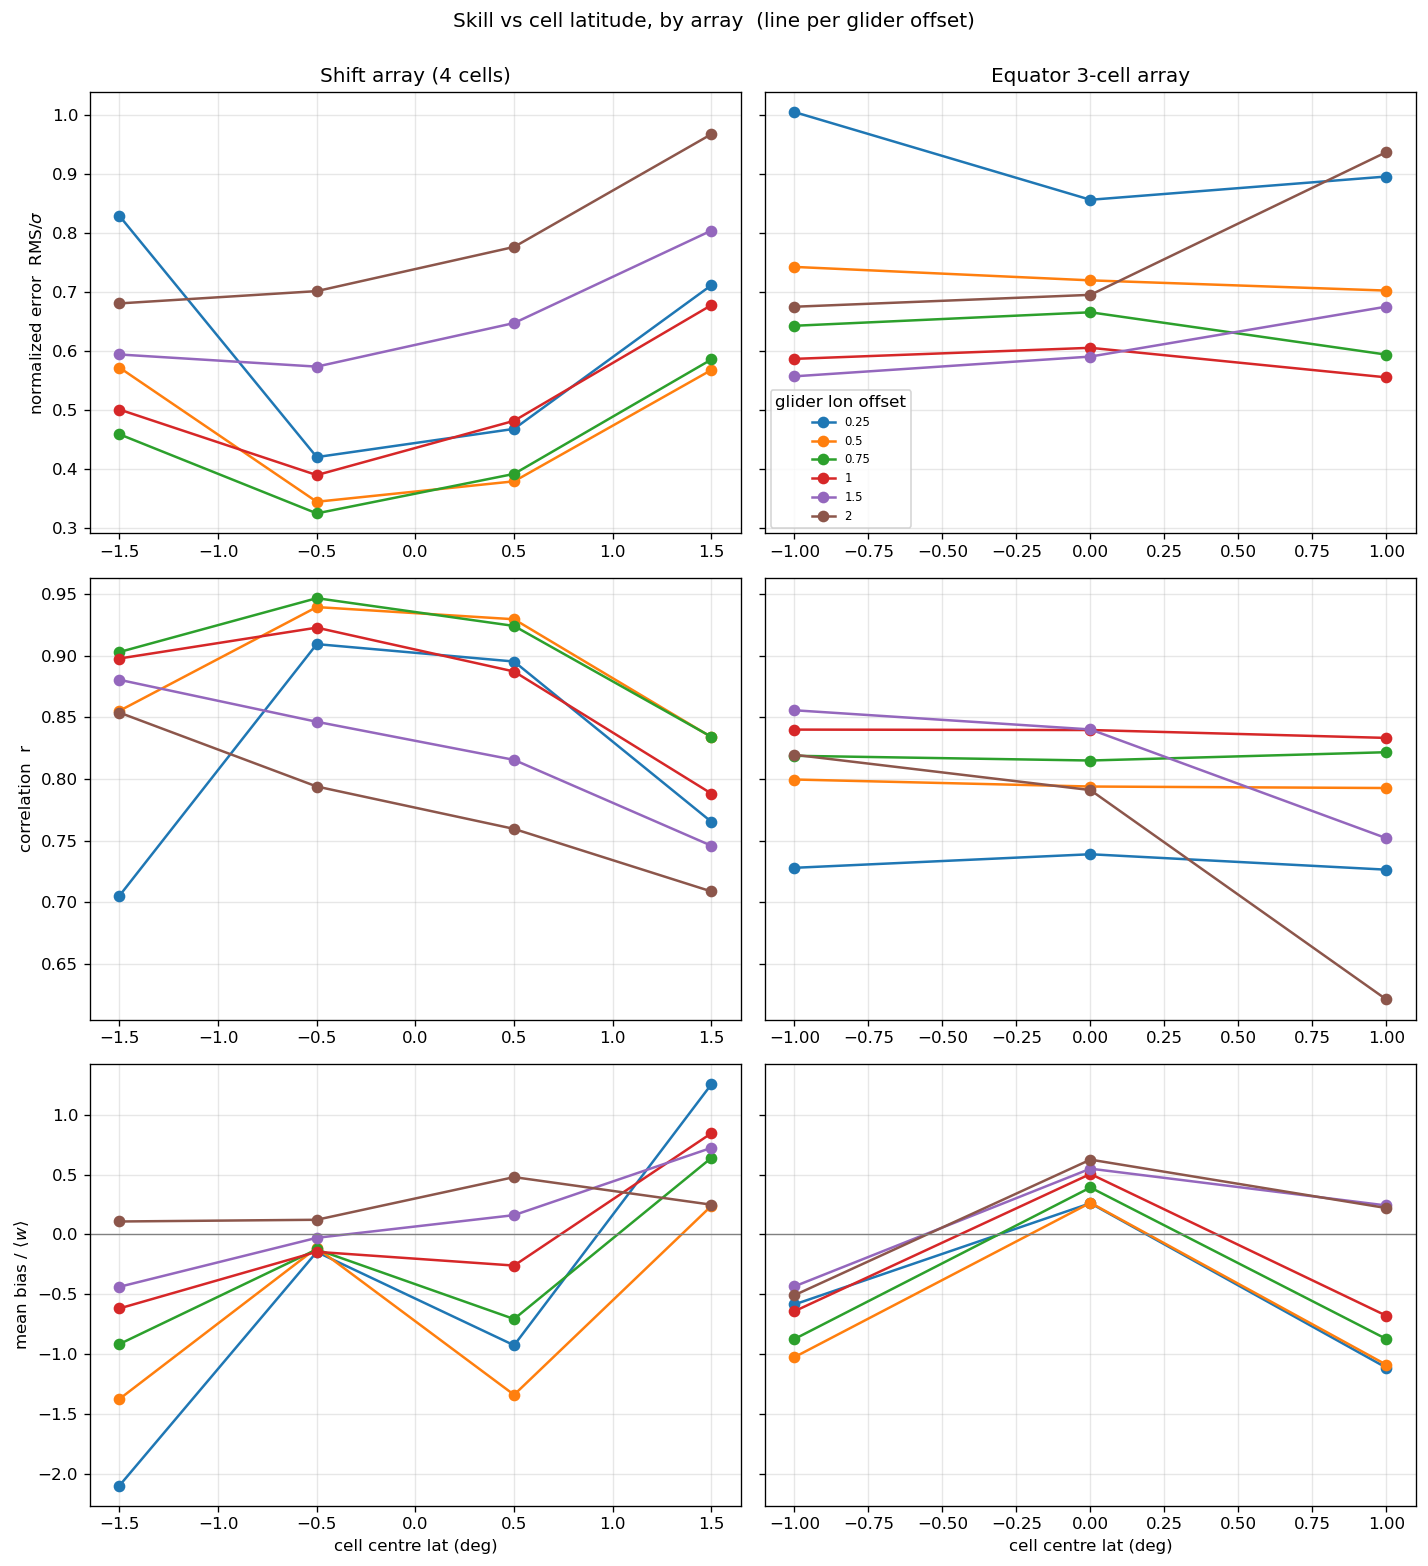

In [5]:
# Figure 3 - skill vs cell latitude for the multi-cell arrays, one line per width.
# The shift array (4 cells) and the equator 3-cell array are the two arrays whose
# cells sit at different latitudes; this shows how each cell's skill depends on
# where it sits, and how that changes with glider offset.
lat_arrays = [("shift", "Shift array (4 cells)"),
              ("equator_3cell", "Equator 3-cell array")]
fig, axes = plt.subplots(3, 2, figsize=(12, 13), sharey="row")
for j, (pat, ptitle) in enumerate(lat_arrays):
    d = m[m.pattern == pat]
    for w, dd in d.groupby("width"):
        dd = dd.sort_values("center_lat")
        axes[0, j].plot(dd.center_lat, dd.norm_rms, "o-", label=f"{w:g}")
        axes[1, j].plot(dd.center_lat, dd["corr"], "o-", label=f"{w:g}")
        axes[2, j].plot(dd.center_lat,
                        ot.frac_mean_bias(dd.mean_bias, dd.w_model_mean),
                        "o-", label=f"{w:g}")
    axes[0, j].set_title(ptitle)
    axes[2, j].set_xlabel("cell centre lat (deg)")
    axes[2, j].axhline(0, color="0.5", lw=0.8)
    for i in (0, 1, 2):
        axes[i, j].grid(alpha=0.3)
axes[0, 0].set_ylabel(r"normalized error  RMS/$\sigma$")
axes[1, 0].set_ylabel("correlation  r")
axes[2, 0].set_ylabel(r"mean bias / $\langle w \rangle$")
axes[0, 1].legend(title="glider lon offset", fontsize=7)
fig.suptitle("Skill vs cell latitude, by array  (line per glider offset)", y=1.0)
fig.tight_layout()
fig.savefig(os.path.join(SUMDIR, "fig3_skill_vs_latitude.png"), dpi=150, bbox_inches="tight")
plt.show()

## Figure 4 - skill vs gliders-per-cell

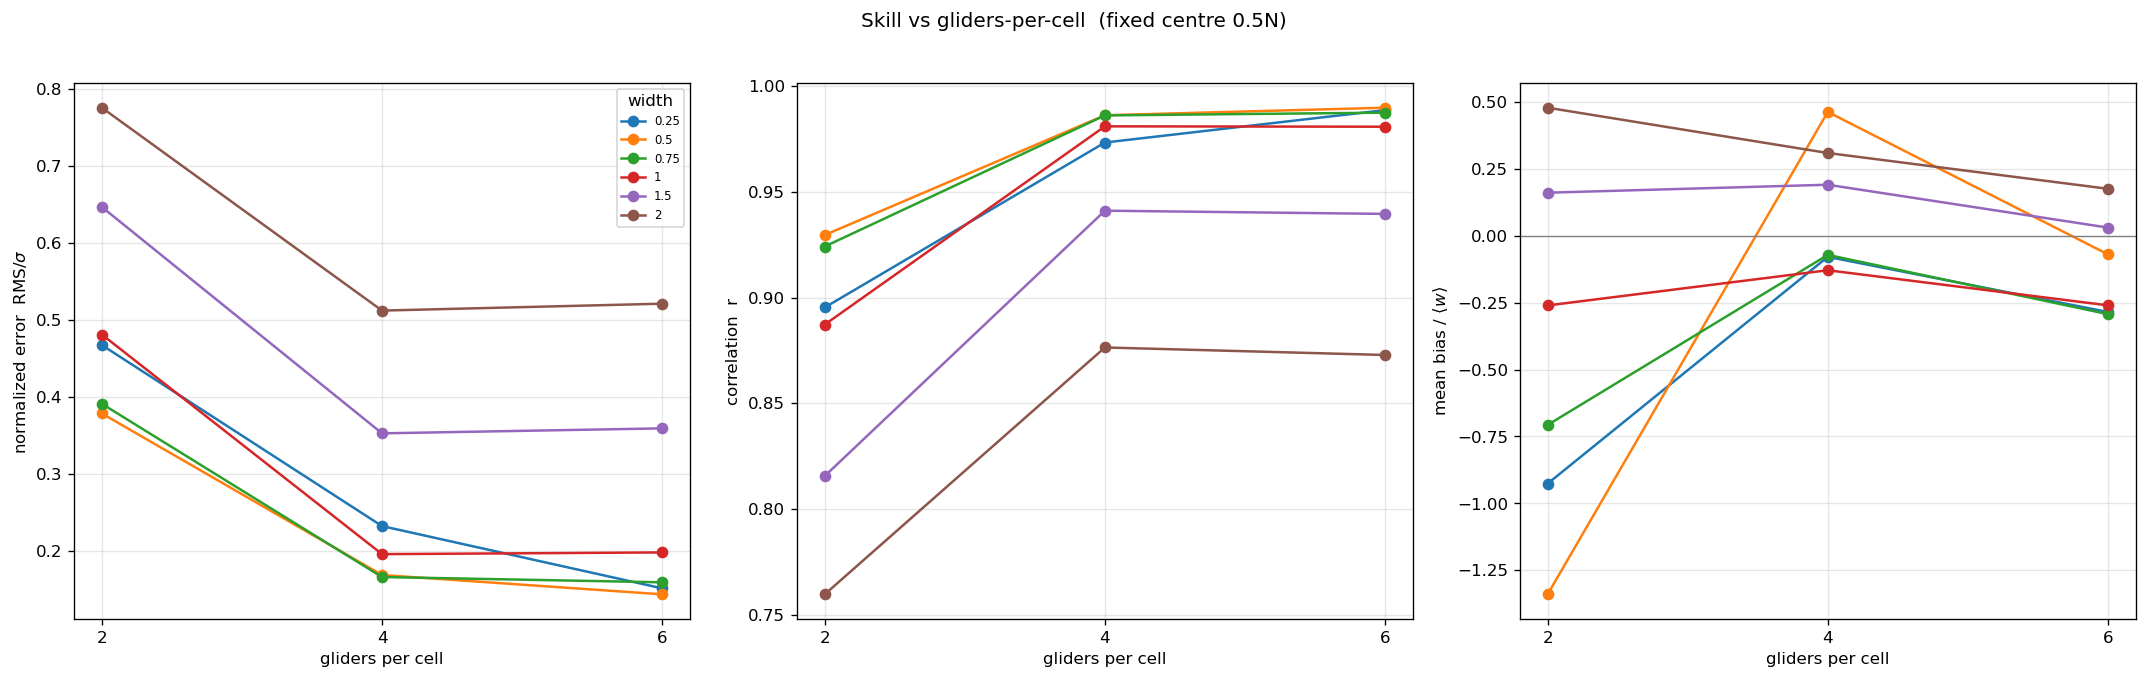

In [6]:
# Figure 4 - skill vs gliders-per-cell at fixed centre 0.5N, one line per width.
d = m[m.family == "density"]
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
for w, dd in d.groupby("width"):
    dd = dd.sort_values("n_gliders_cell")
    axes[0].plot(dd.n_gliders_cell, dd.norm_rms, "o-", label=f"{w:g}")
    axes[1].plot(dd.n_gliders_cell, dd["corr"], "o-", label=f"{w:g}")
    axes[2].plot(dd.n_gliders_cell,
                 ot.frac_mean_bias(dd.mean_bias, dd.w_model_mean), "o-", label=f"{w:g}")
axes[0].set_ylabel(r"normalized error  RMS/$\sigma$")
axes[1].set_ylabel("correlation  r")
axes[2].set_ylabel(r"mean bias / $\langle w \rangle$")
axes[2].axhline(0, color="0.5", lw=0.8)
for ax in axes:
    ax.set_xlabel("gliders per cell"); ax.set_xticks([2, 4, 6]); ax.grid(alpha=0.3)
axes[0].legend(title="width", fontsize=7)
fig.suptitle("Skill vs gliders-per-cell  (fixed centre 0.5N)", y=1.02)
fig.tight_layout()
fig.savefig(os.path.join(SUMDIR, "fig4_skill_vs_gliders.png"), dpi=150, bbox_inches="tight")
plt.show()

## Figures 5a-5d - skill vs depth, within each method

Depth-resolved skill at a fixed glider offset (`DEPTH_WIDTH = 1.0°` for 5a-5c,
`0.5°` for 5d), one figure per method, coloured by the same within-method knob
as 2a-2d — so this evaluates the tunable parameters inside a method, not a
comparison between methods. Panels: normalized error, correlation, fractional
mean bias (⟨w_est⟩−⟨w_model⟩)/⟨w_model⟩ (masked to NaN at the mean's
zero-crossings, where it is undefined), absolute RMS (solid) vs signal std
(dotted), and the mean w profile itself — estimate (solid) vs model truth
(dotted).

- **5a shift** - lines = the 4 cell latitudes.
- **5b equator 3-cell** - lines = the 3 cell latitudes.
- **5c density** - lines = 2 / 4 / 6 gliders-per-cell.
- **5d equator single-cell** - diamond vs hexagon at 1° vs 2° tall, at glider
  offset 0.5° (colour = height, line = shape).

Replaces the old single Figure 5, which averaged over each family's cells and so
hid the within-method dependence.

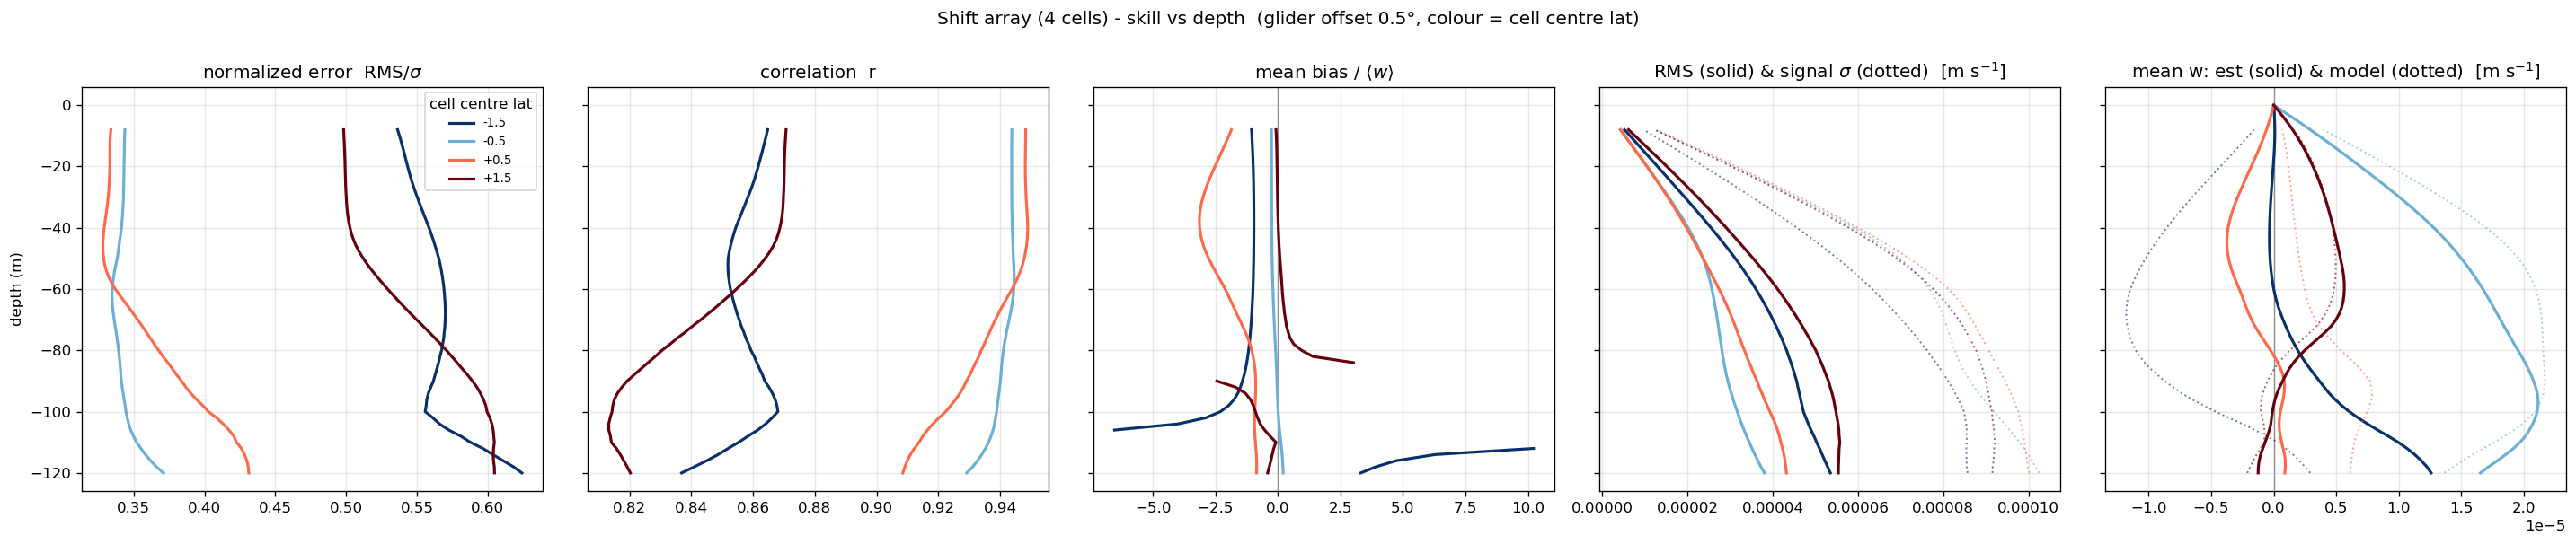

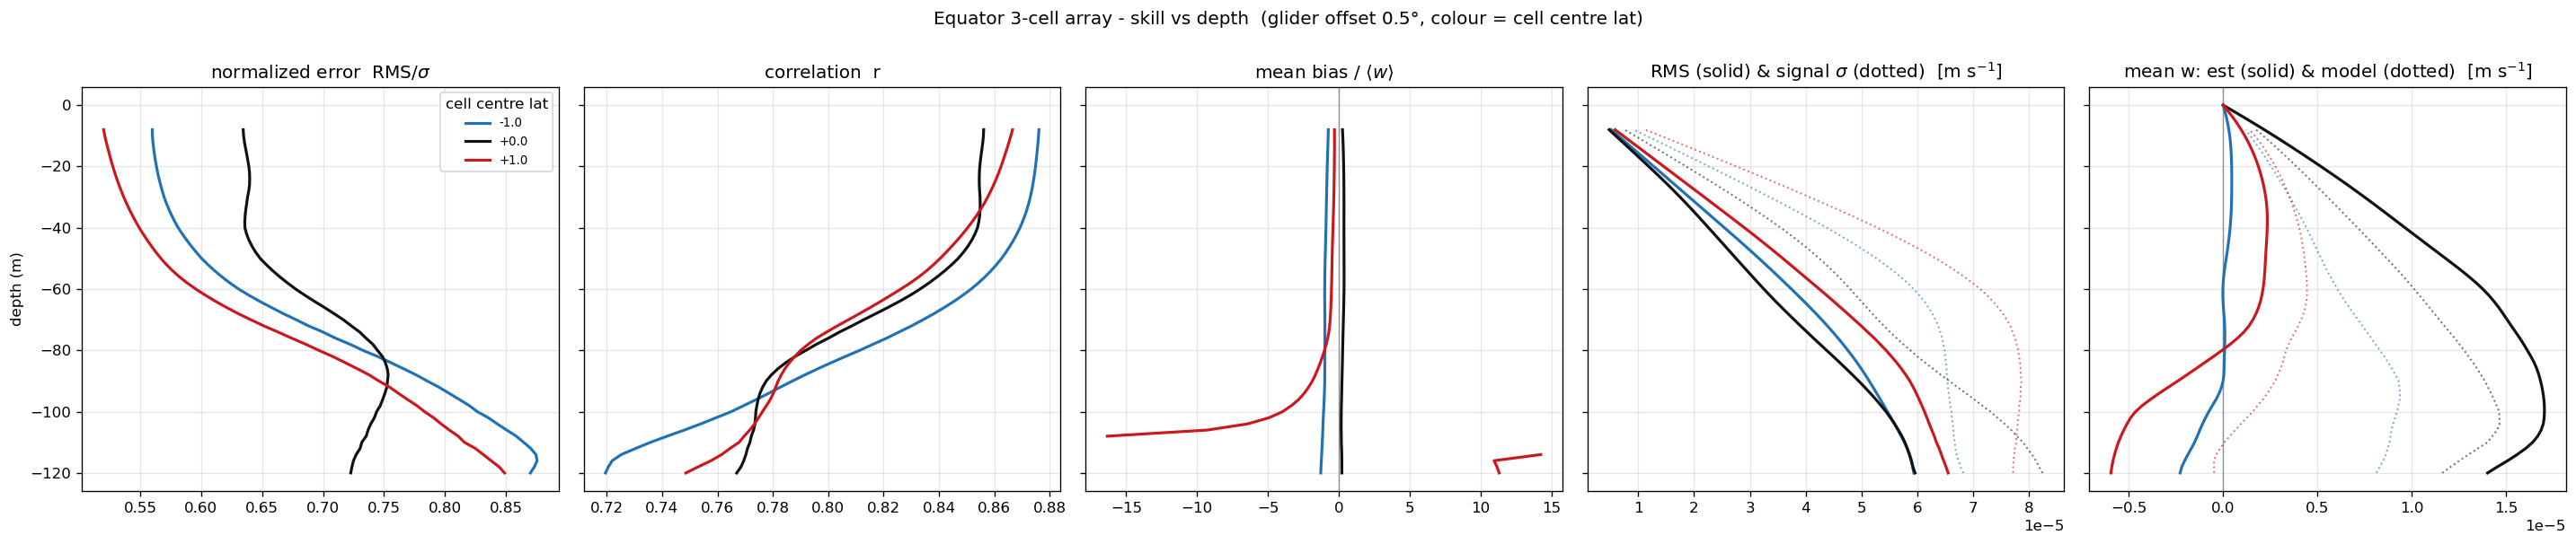

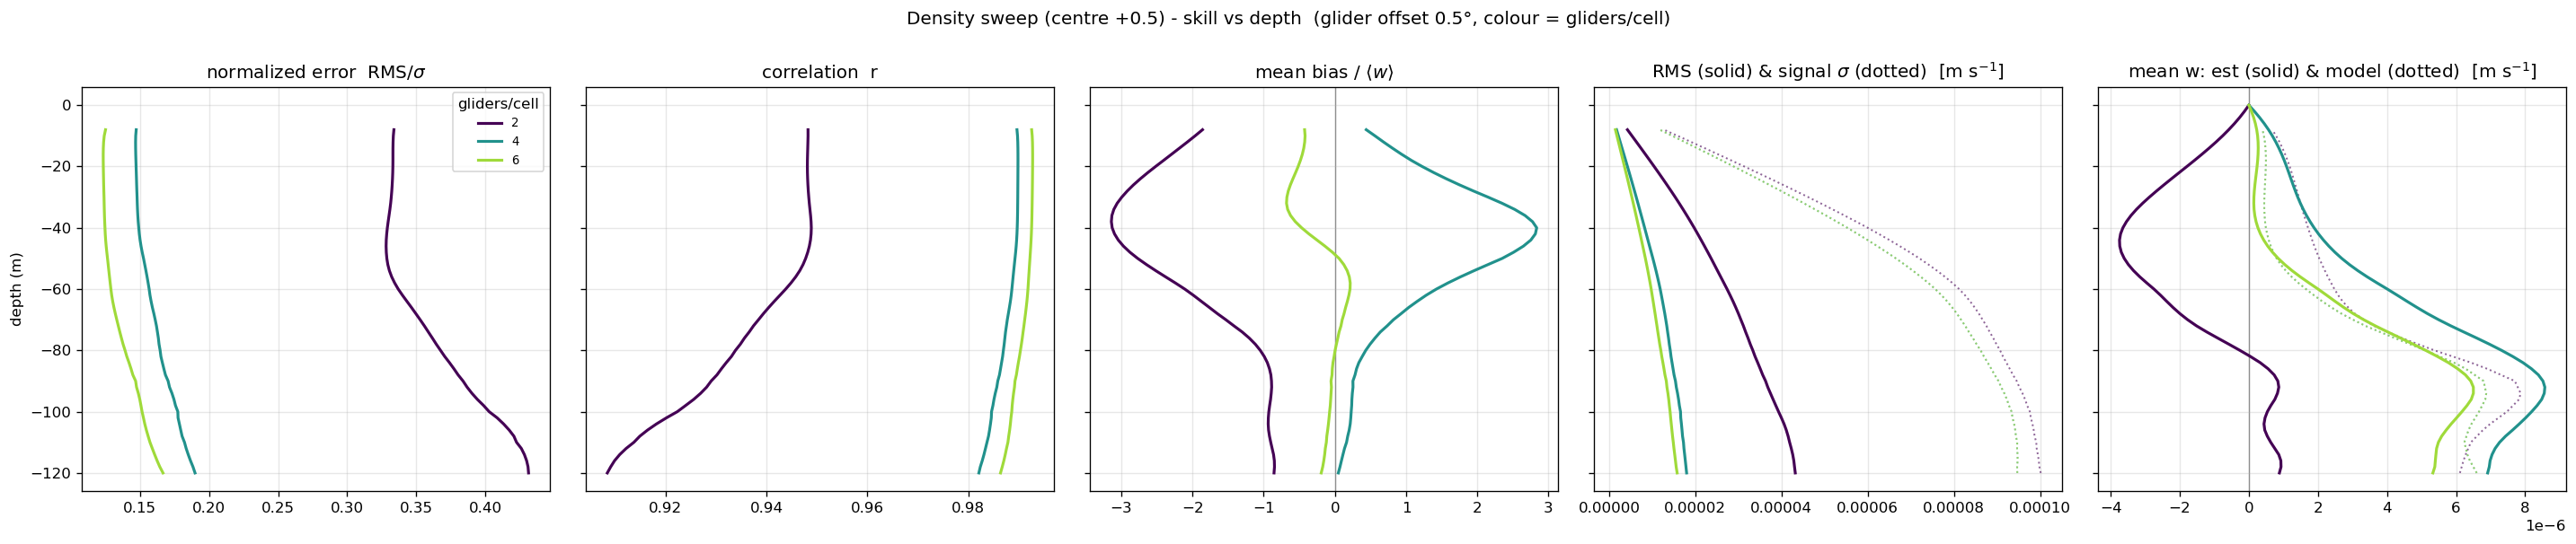

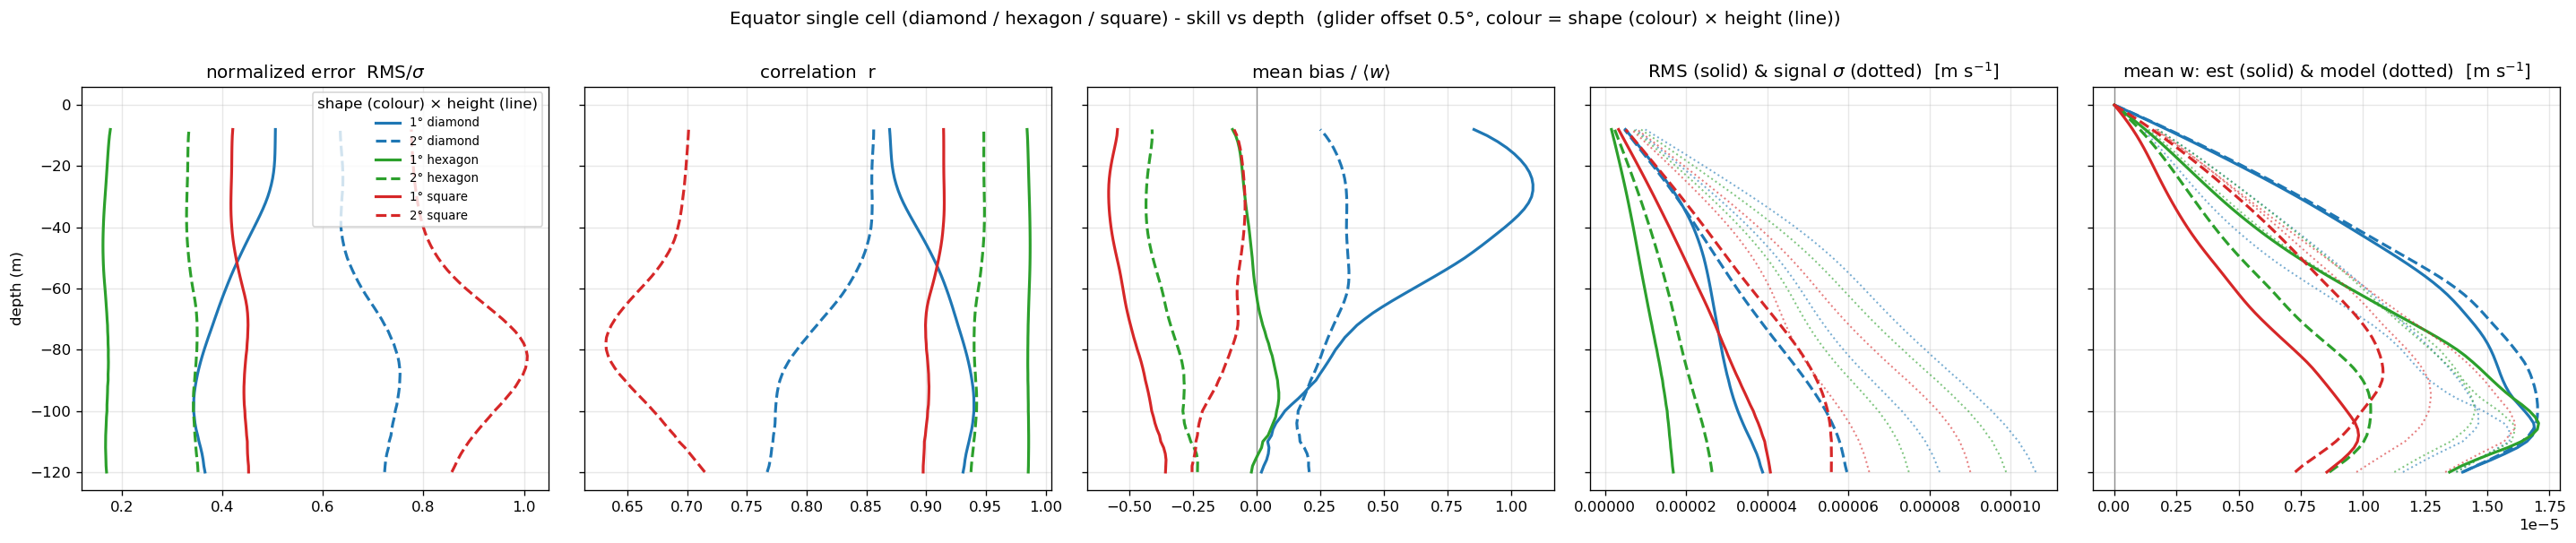

In [7]:
# Figures 5a-5d - skill vs depth, one method per figure, at a fixed glider offset.
# Lines are coloured by the SAME within-method knob as 2a-2d, so each figure
# evaluates the tunable parameters inside one method rather than comparing methods.
# Panels: normalized error, correlation, fractional mean bias (guarded at the
# mean's zero-crossings), absolute RMS (solid) against signal std sigma (dotted),
# and the mean w profile itself (est solid, model dotted). 5a-5c use DEPTH_WIDTH;
# 5d uses the narrower DEPTH_WIDTH_5D glider offset.
DEPTH_WIDTH = 0.5
W = np.isclose(m.width, DEPTH_WIDTH)

def _plot_depth(rows_styles, tag, title, leg_title, dw=DEPTH_WIDTH):
    fig, axes = plt.subplots(1, 5, figsize=(24, 5), sharey=True)
    handles = []
    for r, st in rows_styles:
        ds = load_cell(r)
        B = ot.w_skill_by_depth(ds.w_est, ds.w_model)
        z = B.depth
        axes[0].plot(B.norm_rms, z, color=st["color"], ls=st["ls"], lw=1.9)
        axes[1].plot(B["corr"], z, color=st["color"], ls=st["ls"], lw=1.9)
        axes[2].plot(ot.frac_mean_bias(B.mean_bias, B.w_model_mean), z,
                     color=st["color"], ls=st["ls"], lw=1.9)
        axes[3].plot(B.rms, z, color=st["color"], ls=st["ls"], lw=1.9)
        axes[3].plot(B.w_model_std, z, color=st["color"], ls=":", lw=1.2, alpha=0.6)
        axes[4].plot(B.w_est_mean, z, color=st["color"], ls=st["ls"], lw=1.9)
        axes[4].plot(B.w_model_mean, z, color=st["color"], ls=":", lw=1.2, alpha=0.6)
        handles.append(Line2D([0], [0], color=st["color"], ls=st["ls"], lw=1.9,
                              label=st["lbl"]))
    axes[0].set_title(r"normalized error  RMS/$\sigma$")
    axes[1].set_title("correlation  r")
    axes[2].set_title(r"mean bias / $\langle w \rangle$")
    axes[2].axvline(0, color="0.5", lw=0.8, zorder=0)
    axes[3].set_title(r"RMS (solid) & signal $\sigma$ (dotted)  [m s$^{-1}$]")
    axes[4].set_title(r"mean w: est (solid) & model (dotted)  [m s$^{-1}$]")
    axes[4].axvline(0, color="0.5", lw=0.8, zorder=0)
    axes[0].set_ylabel("depth (m)")
    for ax in axes:
        ax.grid(alpha=0.3)
    axes[0].legend(handles=handles, title=leg_title, fontsize=8)
    fig.suptitle(f"{title} - skill vs depth  (glider offset {dw:g}°, "
                 f"colour = {leg_title})", y=1.0)
    fig.tight_layout()
    fig.savefig(os.path.join(SUMDIR, f"fig{tag}.png"), dpi=150, bbox_inches="tight")
    plt.show()

# 5a shift + 5b equator 3-cell: colour = cell centre latitude
for tag, pat, title in (("5a_shift", "shift", "Shift array (4 cells)"),
                        ("5b_equator3cell", "equator_3cell", "Equator 3-cell array")):
    d = m[(m.pattern == pat) & W]
    rs = [(d[np.isclose(d.center_lat, lat)].iloc[0],
           dict(color=LAT_COLORS[lat], ls="-", lbl=f"{lat:+.1f}"))
          for lat in sorted(d.center_lat.unique())]
    _plot_depth(rs, tag, title, "cell centre lat")

# 5c density: colour = gliders-per-cell
d = m[(m.family == "density") & W]
rs = [(d[d.n_gliders_cell == ng].iloc[0],
       dict(color=GLIDER_COLORS[ng], ls="-", lbl=f"{int(ng)}"))
      for ng in sorted(d.n_gliders_cell.unique())]
_plot_depth(rs, "5c_density", "Density sweep (centre +0.5)", "gliders/cell")

# 5d equator single: diamond vs hexagon x 1deg/2deg (colour = height, line = shape)
# uses the narrower DEPTH_WIDTH_5D glider offset.
d = m[W]
rs = [(d[d.pattern == pat].iloc[0],
       dict(color=EQS_STYLE[pat]["color"], ls=EQS_STYLE[pat]["ls"],
            lbl=EQS_STYLE[pat]["lbl"]))
      for pat in EQS_PATS if (d.pattern == pat).any()]
_plot_depth(rs, "5d_equator_single", "Equator single cell (diamond / hexagon / square)",
            "shape (colour) × height (line)", dw=DEPTH_WIDTH)

## Figure 6 - metric heatmaps (all configs at a glance)

One "colored square" per (config cell, width) so visual patterns across the
sweep are immediately readable. Rows are estimate cells (sampling pattern @
centre latitude, grouped by family), columns are glider lon offset (array
width). Three panels for the three skill metrics: RMS/sigma (lower better),
correlation (higher better), and mean bias / sigma (0 = unbiased). Colour is
a scan aid layered on the printed value; sequential maps run light = good ->
dark = poor, the diverging bias map is white at zero. Still plain descriptive
stats - no thresholds or 'best config' calls.

**Figures 6a-6d** repeat this grid one method at a time (same split as fig2a-2d / fig5a-5d): 6a shift, 6b equator 3-cell, 6c density, 6d equator single-cell. Each sub-figure auto-scales its own colour range, so read colour within a figure; the printed values stay directly comparable to fig6.

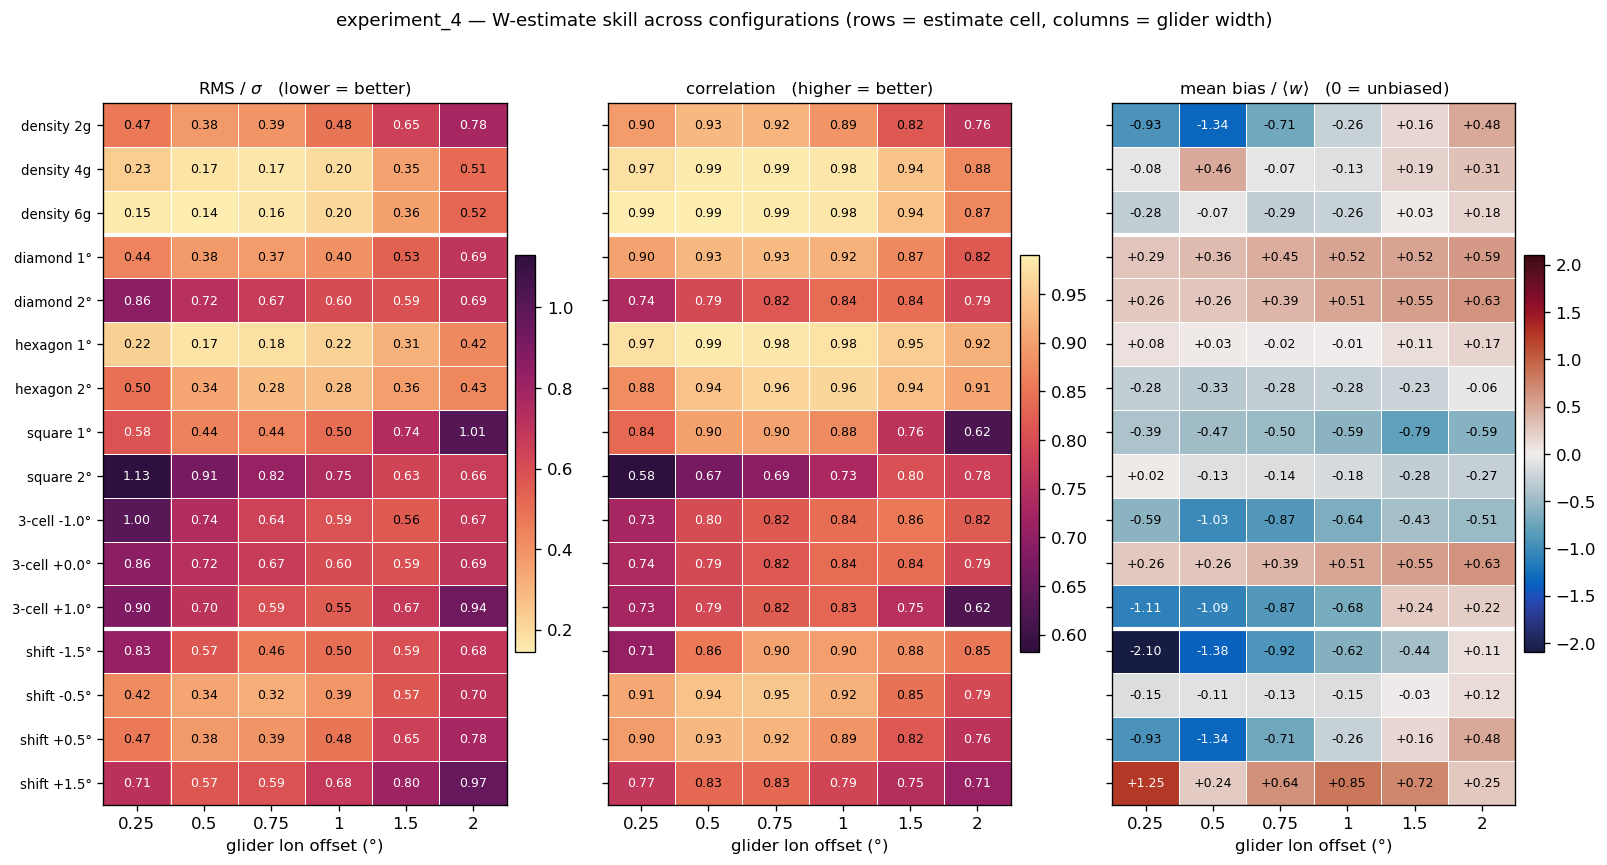

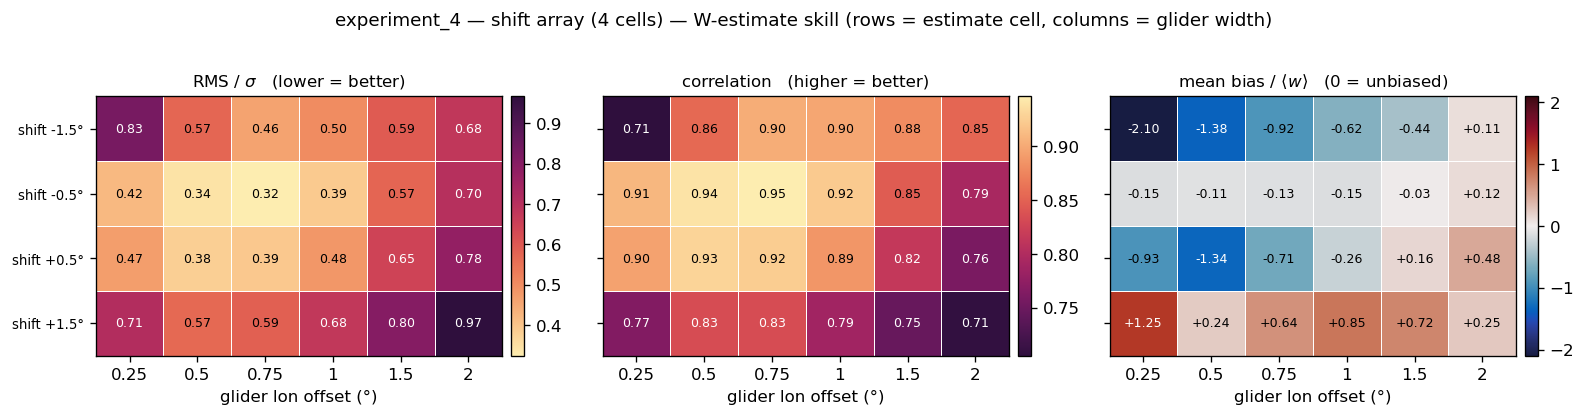

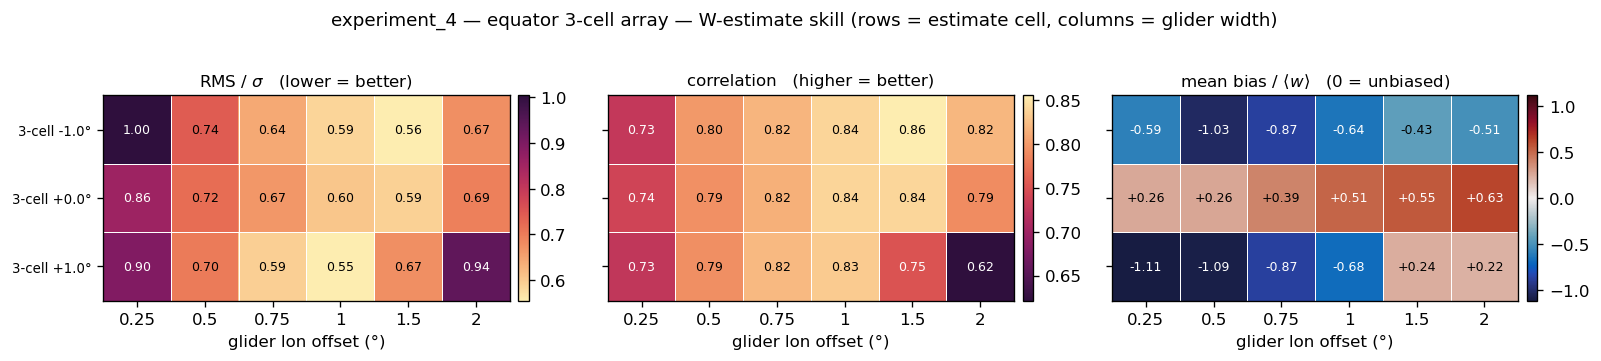

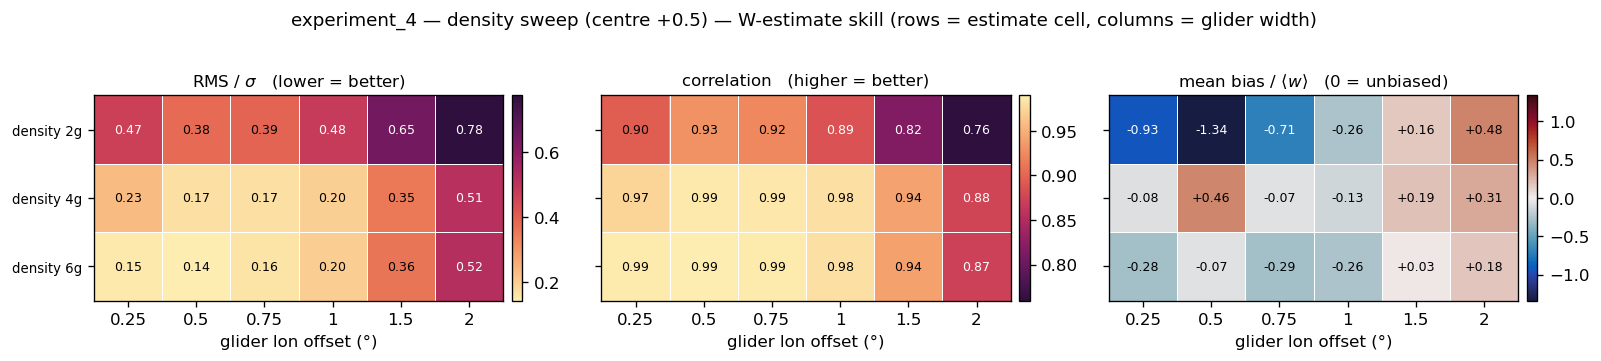

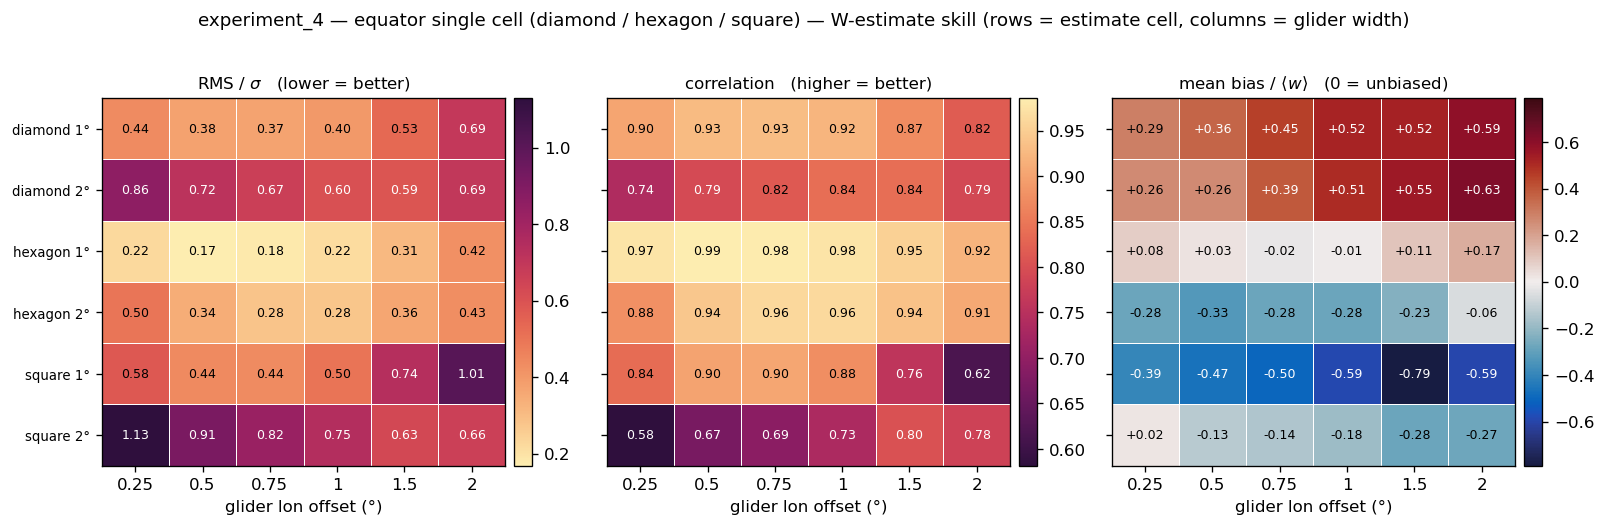

In [8]:
# Figure 6 - metric heatmaps (ML-style "colored squares") summarizing every
# config in one view. rows = estimate cell (sampling pattern @ centre latitude),
# columns = glider lon offset (array width); one panel per metric. Colour is a
# scan aid on top of the printed value: sequential cmocean.matter for RMS/sigma
# and correlation (light = good, dark = poor, consistent direction), diverging
# balance for bias centred on zero (white = unbiased). Bias uses the same
# fractional normalisation as fig2-5 (frac_mean_bias = bias / <w_model>, guarded
# at the mean's zero-crossings) so the numbers match the other summary figures.
# fig6 shows every family at once; fig6a-6d break it out one method per figure
# (same split as fig2a-2d / fig5a-5d) so each method's grid reads on its own.
import cmocean
from matplotlib.colors import TwoSlopeNorm

EXP = os.path.basename(HERE)
mb = m.copy()
mb["frac_bias"] = ot.frac_mean_bias(mb["mean_bias"].values, mb["w_model_mean"].values)

WIDTHS = [0.25, 0.5, 0.75, 1.0, 1.5, 2.0]

PAT_LABEL = {
    "density_2g": "density 2g", "density_4g": "density 4g", "density_6g": "density 6g",
    "equator_1deg": "diamond 1°", "equator_2deg": "diamond 2°",
    "equator_hex1deg": "hexagon 1°", "equator_hex2deg": "hexagon 2°",
    "equator_sq1deg": "square 1°", "equator_sq2deg": "square 2°",
    "equator_3cell": "3-cell", "shift": "shift",
}
ORDER = [
    ("density_2g", 0.5), ("density_4g", 0.5), ("density_6g", 0.5),
    ("equator_1deg", 0.0), ("equator_2deg", 0.0),
    ("equator_hex1deg", 0.0), ("equator_hex2deg", 0.0),
    ("equator_sq1deg", 0.0), ("equator_sq2deg", 0.0),
    ("equator_3cell", -1.0), ("equator_3cell", 0.0), ("equator_3cell", 1.0),
    ("shift", -1.5), ("shift", -0.5), ("shift", 0.5), ("shift", 1.5),
]
def _row_label(pat, lat):
    base = PAT_LABEL.get(pat, pat)
    return f"{base} {lat:+.1f}°" if pat in ("equator_3cell", "shift") else base
def _fam(pat):
    return "density" if pat.startswith("density") else "shift" if pat == "shift" else "equator"

def _grid(metric, order):
    g = np.full((len(order), len(WIDTHS)), np.nan)
    for i, (pat, lat) in enumerate(order):
        for j, w in enumerate(WIDTHS):
            sel = mb[(mb["pattern"] == pat) & np.isclose(mb["center_lat"], lat)
                     & np.isclose(mb["width"], w)]
            if len(sel):
                g[i, j] = sel.iloc[0][metric]
    return g

panels = [
    ("norm_rms",  r"RMS / $\sigma$   (lower = better)",      cmocean.cm.matter,   None,  "{:.2f}"),
    ("corr",      "correlation   (higher = better)",          cmocean.cm.matter_r, None,  "{:.2f}"),
    ("frac_bias", r"mean bias / $\langle w \rangle$   (0 = unbiased)", cmocean.cm.balance, "div", "{:+.2f}"),
]

def _heatmap_fig(order, fname, suptitle, figsize):
    nrows = len(order)
    fig, axes = plt.subplots(1, 3, figsize=figsize, sharey=True)
    for ax, (metric, title, cmap, kind, fmt) in zip(axes, panels):
        G = _grid(metric, order)
        if kind == "div":
            vmax = np.nanmax(np.abs(G))
            im = ax.imshow(G, aspect="auto", cmap=cmap,
                           norm=TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax))
        else:
            im = ax.imshow(G, aspect="auto", cmap=cmap)
        rgba = im.cmap(im.norm(G))
        lum = 0.299 * rgba[..., 0] + 0.587 * rgba[..., 1] + 0.114 * rgba[..., 2]
        for i in range(nrows):
            for j in range(len(WIDTHS)):
                if not np.isnan(G[i, j]):
                    ax.text(j, i, fmt.format(G[i, j]), ha="center", va="center",
                            fontsize=7.5, color="white" if lum[i, j] < 0.5 else "black")
        ax.set_xticks(range(len(WIDTHS)))
        ax.set_xticklabels([f"{w:g}" for w in WIDTHS])
        ax.set_xlabel("glider lon offset (°)")
        ax.set_title(title, fontsize=10)
        for i in range(1, nrows):
            if _fam(order[i][0]) != _fam(order[i - 1][0]):
                ax.axhline(i - 0.5, color="white", lw=2.5)
        ax.set_xticks(np.arange(-0.5, len(WIDTHS), 1), minor=True)
        ax.set_yticks(np.arange(-0.5, nrows, 1), minor=True)
        ax.grid(which="minor", color="white", lw=0.6)
        ax.tick_params(which="minor", length=0)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
    axes[0].set_yticks(range(nrows))
    axes[0].set_yticklabels([_row_label(p, l) for p, l in order], fontsize=8)
    fig.suptitle(suptitle, fontsize=11, y=0.995)
    fig.tight_layout(rect=[0, 0, 1, 0.98])
    fig.savefig(os.path.join(SUMDIR, fname), dpi=150, bbox_inches="tight")
    plt.show()

# Figure 6 - all families in one view
_heatmap_fig(ORDER, "fig6_metric_heatmaps.png",
             f"{EXP} — W-estimate skill across configurations "
             "(rows = estimate cell, columns = glider width)",
             figsize=(13.5, 7.2))

# Figures 6a-6d - one method per figure (same split as fig2a-2d / fig5a-5d).
# Each grid auto-scales its own colour range, so read colour within a figure.
EQS_ROWS = ["equator_1deg", "equator_2deg", "equator_hex1deg",
            "equator_hex2deg", "equator_sq1deg", "equator_sq2deg"]
SUB_ORDERS = [
    ("6a_shift", "shift array (4 cells)",
     [o for o in ORDER if o[0] == "shift"]),
    ("6b_equator3cell", "equator 3-cell array",
     [o for o in ORDER if o[0] == "equator_3cell"]),
    ("6c_density", "density sweep (centre +0.5)",
     [o for o in ORDER if o[0].startswith("density")]),
    ("6d_equator_single", "equator single cell (diamond / hexagon / square)",
     [o for o in ORDER if o[0] in EQS_ROWS]),
]
for tag, label, order in SUB_ORDERS:
    _heatmap_fig(order, f"fig{tag}.png",
                 f"{EXP} — {label} — W-estimate skill "
                 "(rows = estimate cell, columns = glider width)",
                 figsize=(13.5, max(2.8, 0.46 * len(order) + 1.6)))
